In [2]:
# fed-74 chat math
# file = '/scratch/ps9044/fedllm/output/MetaMathQA7_BeaverTails3_500_fedavg_c10s3_i10_b16a1_l512_r32a64_20251013210832/cos_total.pkl'
file = '/scratch/ps9044/fedllm/output/WildChat7_BeaverTails3_500_fedavg_c10s3_i10_b16a1_l512_r32a64_20251023213245/cos_total.pkl'
import pickle
with open(file, 'rb') as f:
    data = pickle.load(f)
import numpy as np



In [6]:
client_benign_ids = [0,1,2,3,4,5,6]
client_malicious_ids = [7,8,9]

avg_benigns = []
avg_malicious = []

import matplotlib.pyplot as plt
for round_idx, round_data in enumerate(data):
    benign_cos_sims = []
    malicious_cos_sims = []
    for client_dict in round_data:
        client_id = client_dict['client']
        cos_sim = np.mean(client_dict['cos_total_whole'][:10])
        if client_id in client_benign_ids:
            benign_cos_sims.append(cos_sim)
        elif client_id in client_malicious_ids:
            malicious_cos_sims.append(cos_sim)
    avg_benign_cos_sim = np.mean(benign_cos_sims)
    avg_malicious_cos_sim = np.mean(malicious_cos_sims)
    avg_benigns.append(avg_benign_cos_sim)
    avg_malicious.append(avg_malicious_cos_sim)

plt.plot(avg_benigns, label='Benign Clients')
plt.plot(avg_malicious, label='Malicious Clients')
plt.xlabel('Communication Round')
plt.ylabel('Average Cosine Similarity')
plt.title('Average Cosine Similarity Over Rounds')
plt.legend()
plt.show()


TypeError: string indices must be integers

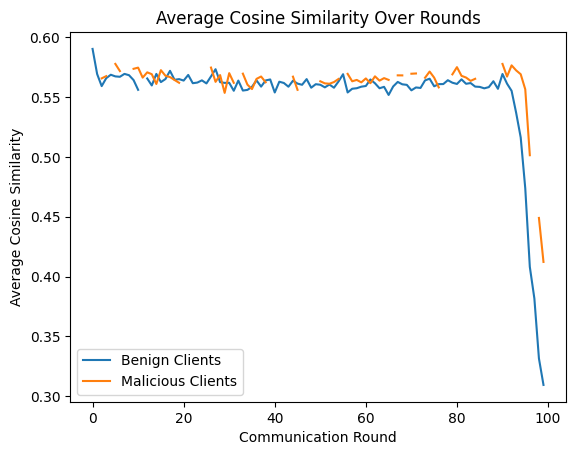

In [9]:
client_benign_ids = [0,1,2,3,4,5,6]
client_malicious_ids = [7,8,9]

avg_benigns = []
avg_malicious = []

import matplotlib.pyplot as plt
for round_idx, round_data in enumerate(data):
    benign_cos_sims = []
    malicious_cos_sims = []
    for client_dict in round_data:
        client_id = client_dict['client']
        cos_sim = np.mean(client_dict['cos_total_delta'][:40])
        if client_id in client_benign_ids:
            benign_cos_sims.append(cos_sim)
        elif client_id in client_malicious_ids:
            malicious_cos_sims.append(cos_sim)
    avg_benign_cos_sim = np.mean(benign_cos_sims)
    avg_malicious_cos_sim = np.mean(malicious_cos_sims)
    avg_benigns.append(avg_benign_cos_sim)
    avg_malicious.append(avg_malicious_cos_sim)

plt.plot(avg_benigns, label='Benign Clients')
plt.plot(avg_malicious, label='Malicious Clients')
plt.xlabel('Communication Round')
plt.ylabel('Average Cosine Similarity')
plt.title('Average Cosine Similarity Over Rounds')
plt.legend()
plt.show()

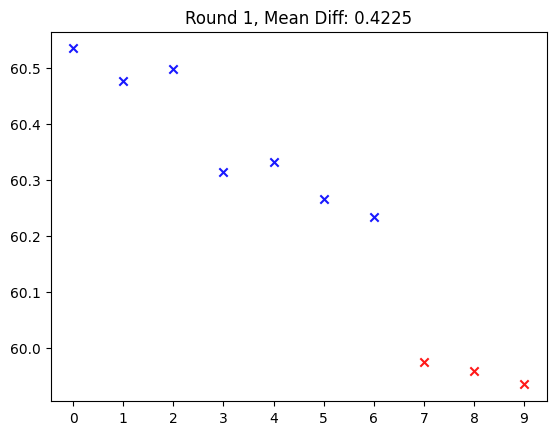

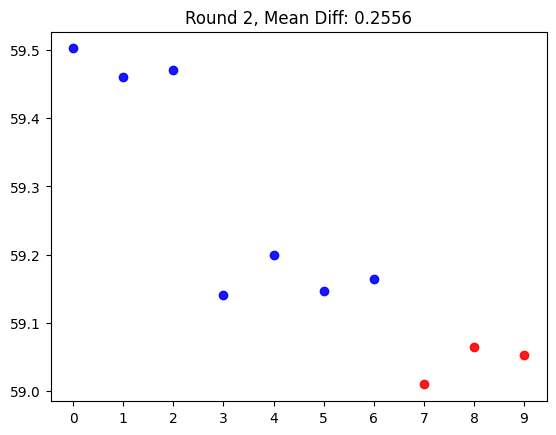

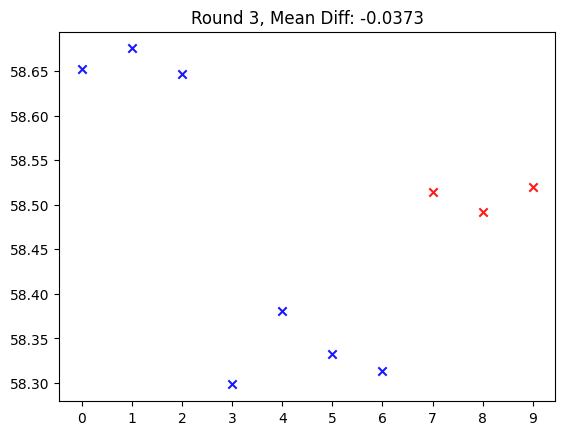

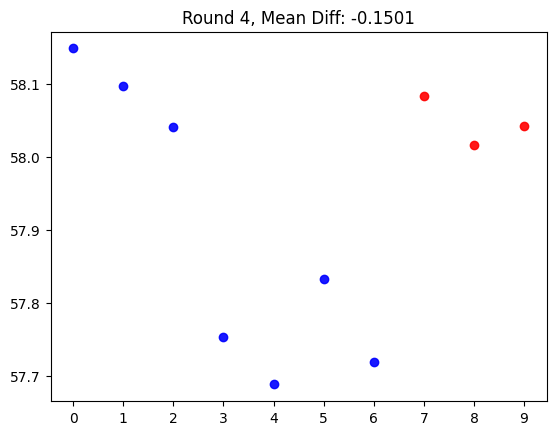

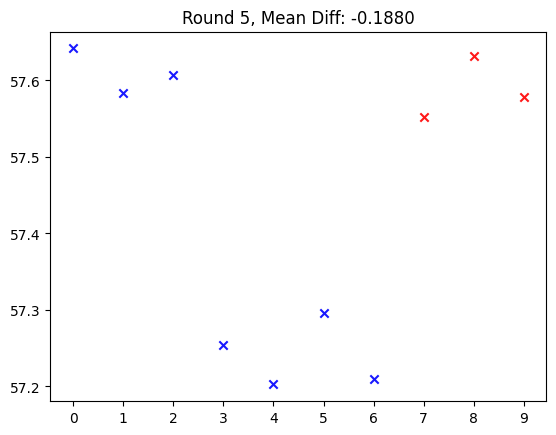

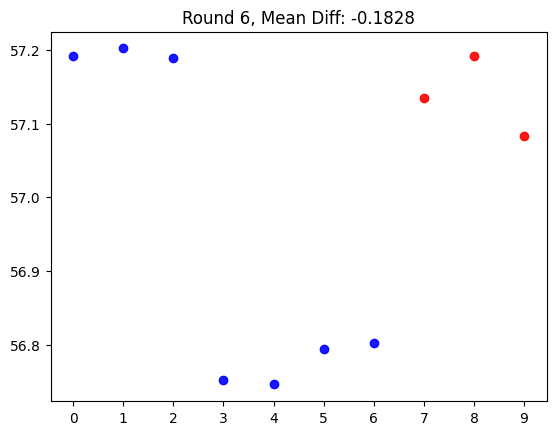

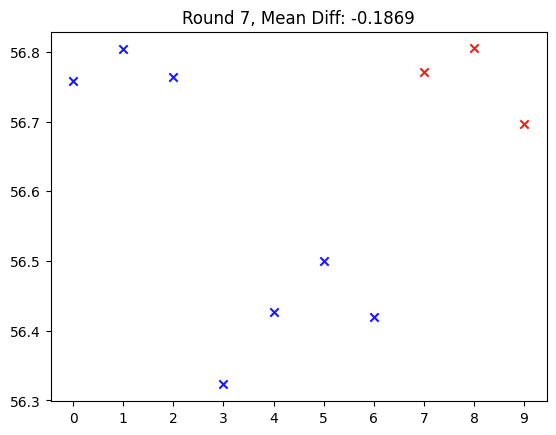

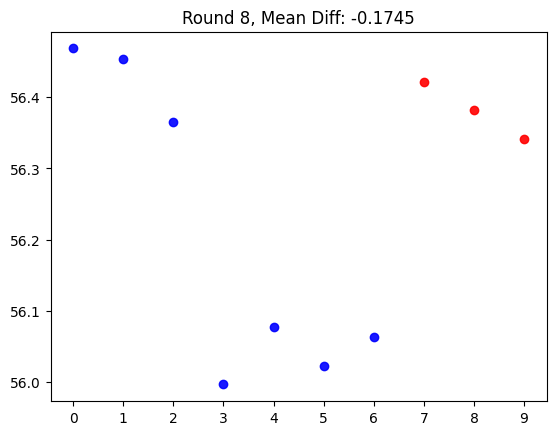

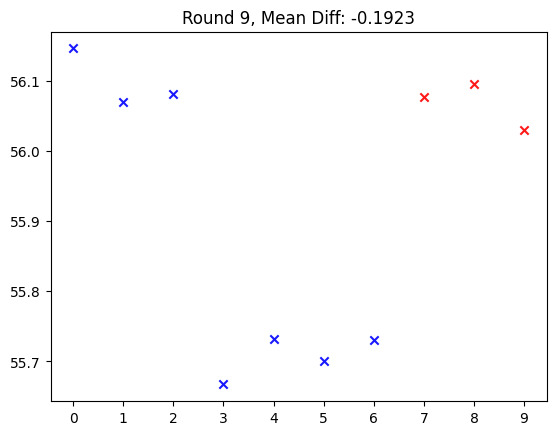

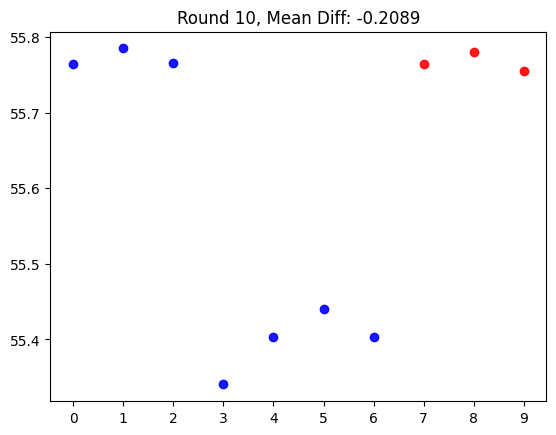

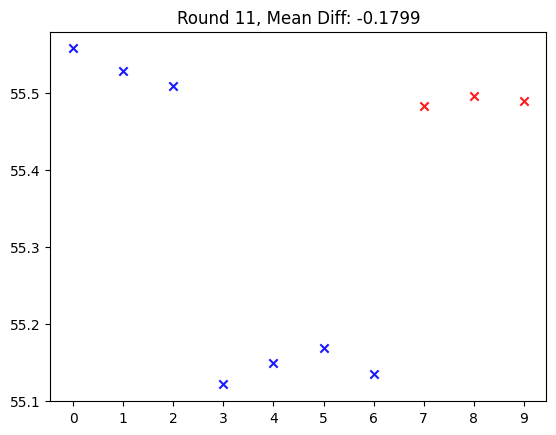

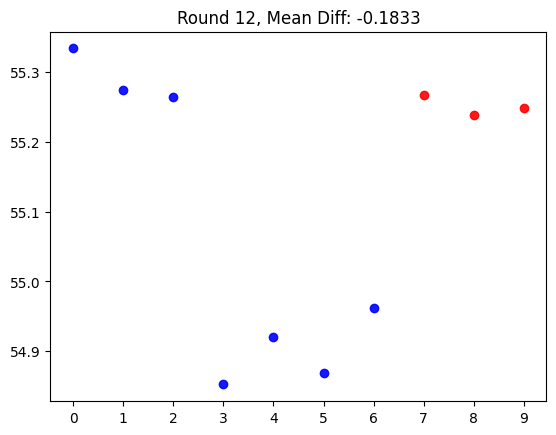

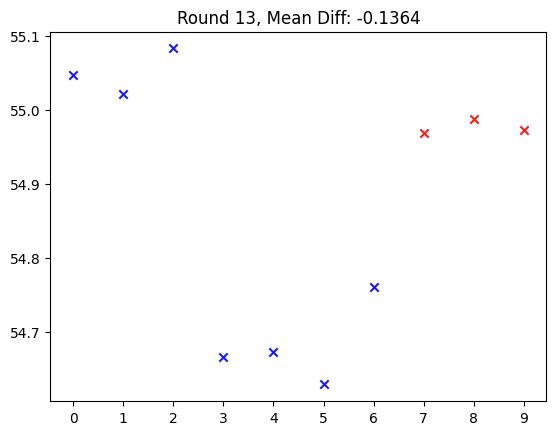

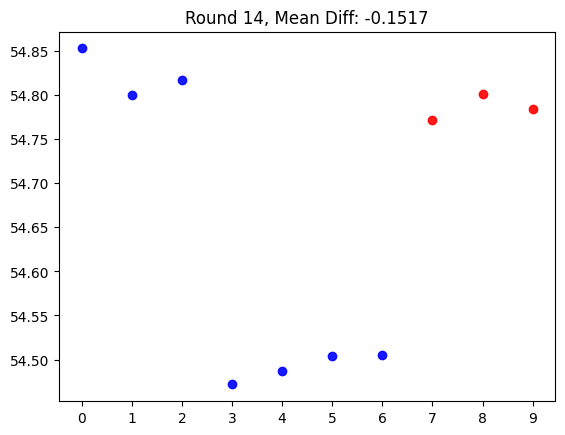

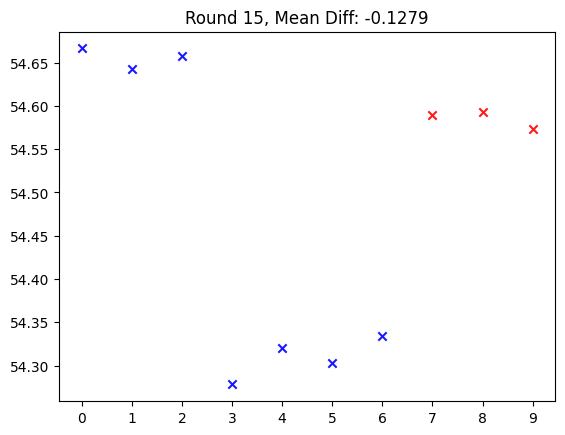

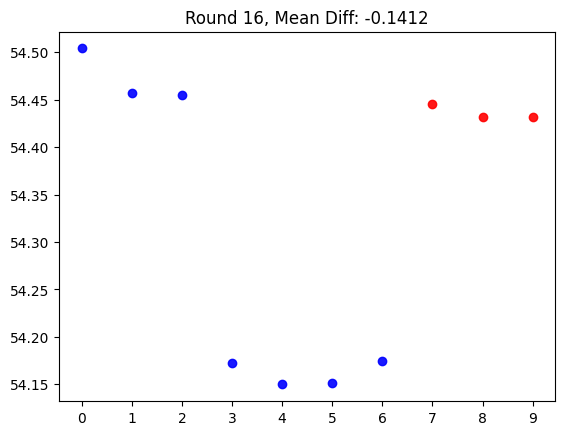

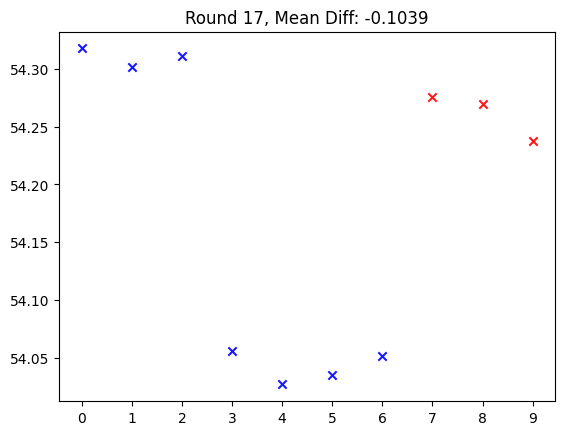

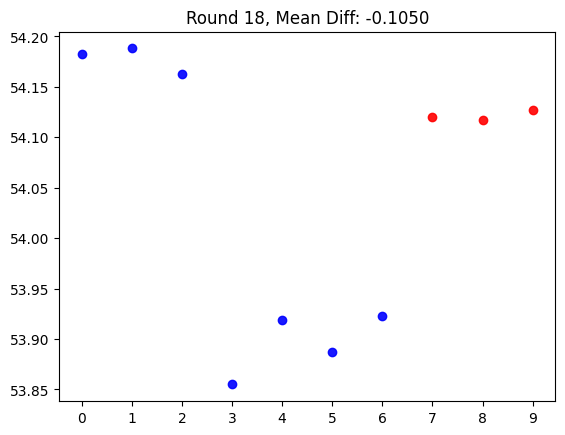

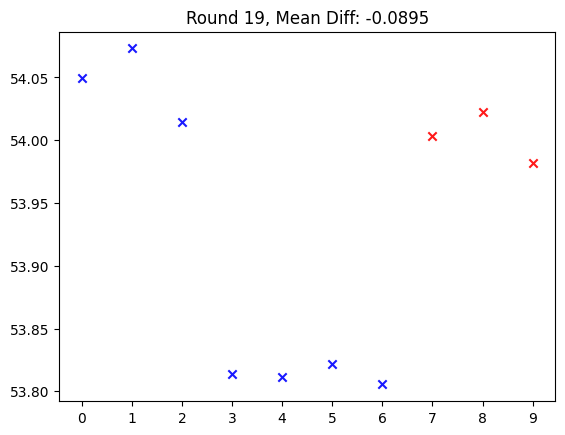

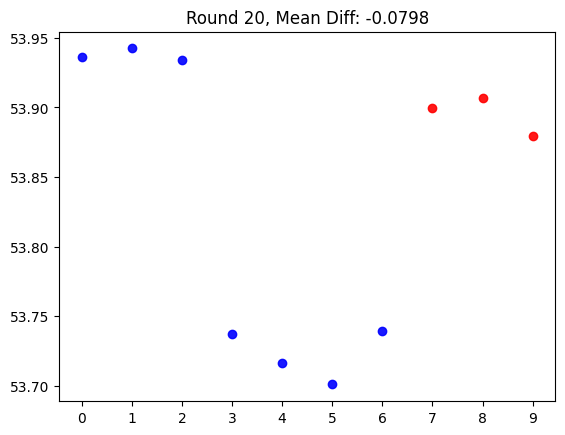

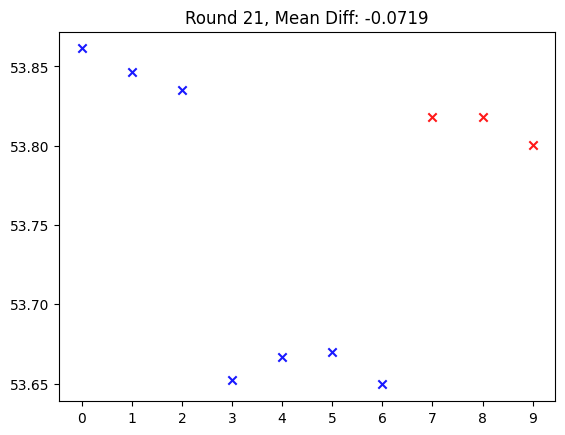

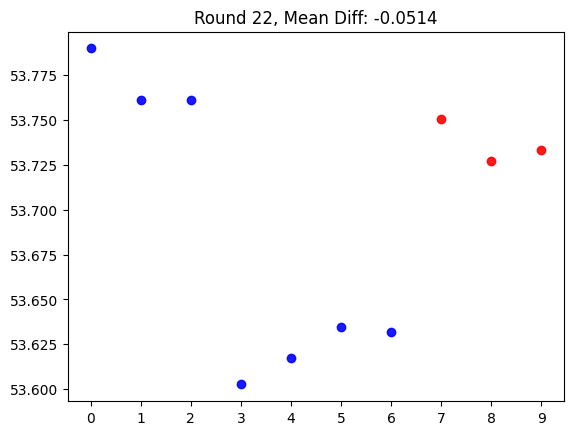

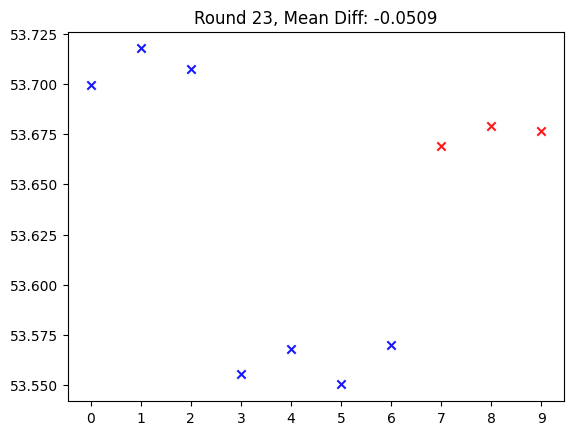

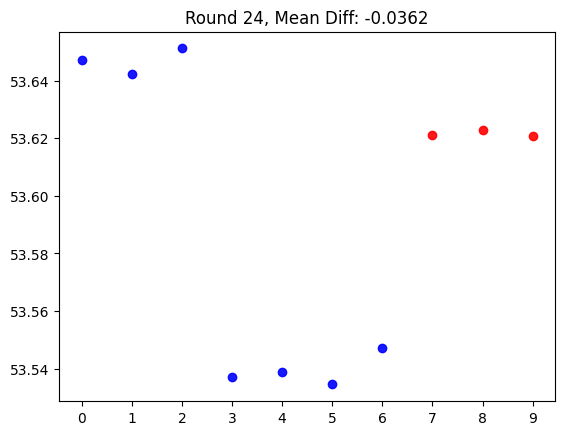

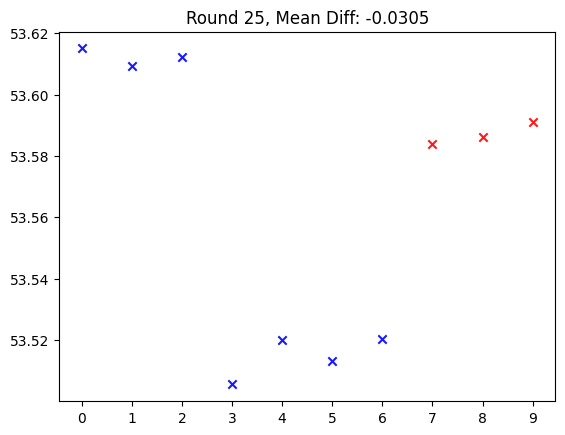

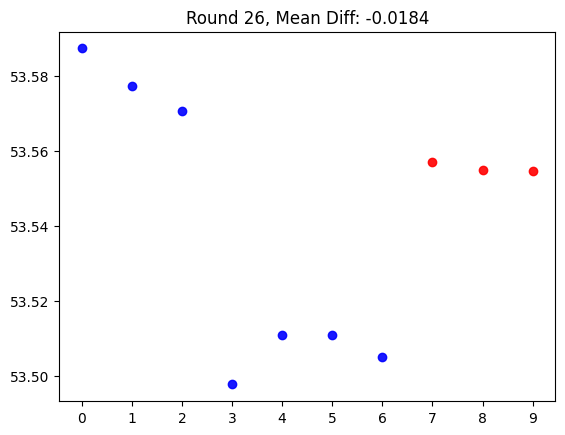

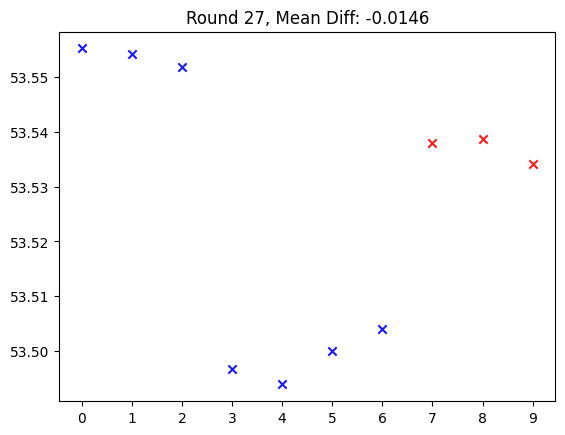

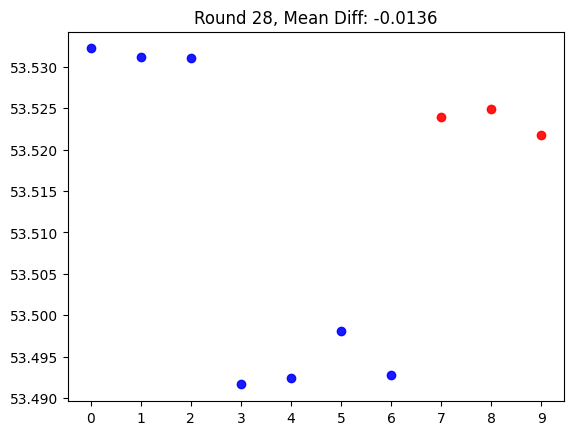

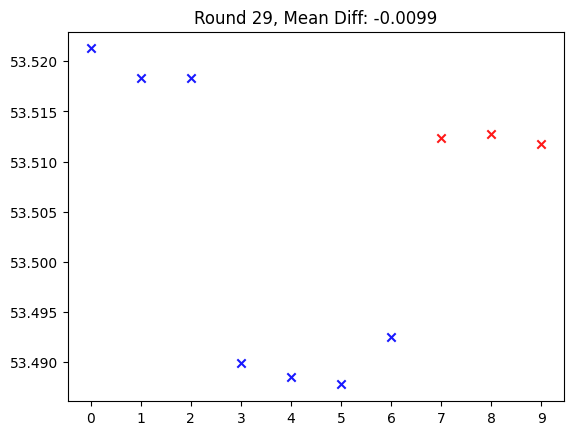

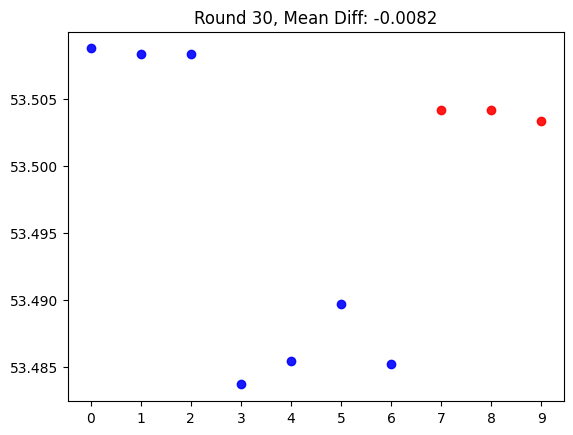

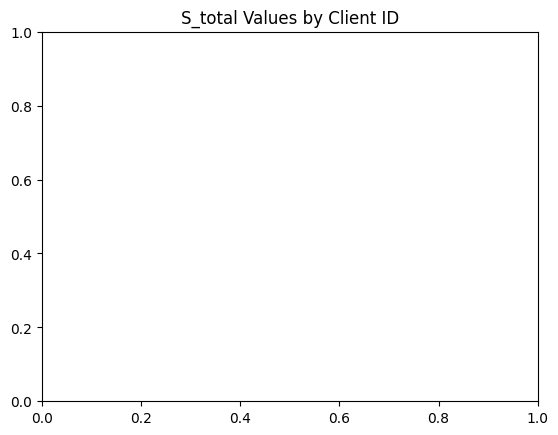

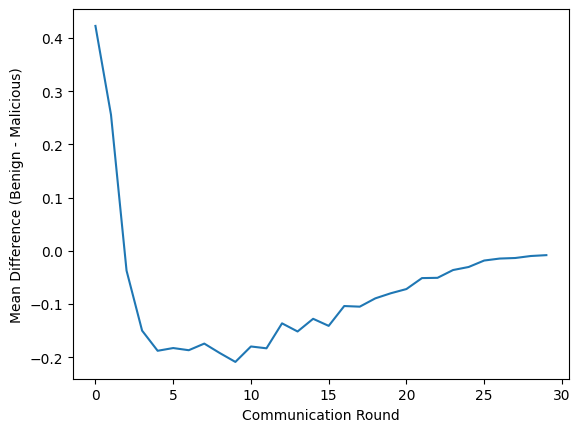

In [1]:
client_benign_ids = [0,1,2,3,4,5,6]
client_malicious_ids = [7,8,9]
import numpy as np
# file_path = '/home/ps9044/test/FedLLM-Attack/output/safelora/meta-llama/Llama-2-7b-chat-hf/C10_N30_benign[7]_malicious[3]_Steps[10]_Clients[10]'
# file_path = '/scratch/ps9044/fedllm/barebones/WildChat7_lmsys3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109213209'
# file_path = '/home/ps9044/test/FedLLM-Attack/output/safelora/meta-llama/Llama-2-7b-chat-hf/C10_N30_benign[7]_malicious[3]_Steps[10]_Clients[10]_ISA[True]'
# file_path = '/home/ps9044/test/FedLLM-Attack/output/safelora/meta-llama/Llama-2-7b-chat-hf/C10_N30_benign[2_2_2]_malicious[2_2]_Steps[10]_Clients[10]'
# file_path = '/home/ps9044/test/FedLLM-Attack/output/safelora/meta-llama/Llama-2-7b-chat-hf/C10_N30_benign[7][zhiqings/dromedary-65b-verbose-clone-v0]_malicious[3][PKU-Alignment/BeaverTails]_Steps[10]_Clients[10]_ISA[False]'
# file_path = '/home/ps9044/test/FedLLM-Attack/output/safelora/meta-llama/Llama-2-7b-chat-hf/C10_N30_benign[2_2_2]_malicious[2_2]_Steps[10]_Clients[10]'
file_path = '/home/ps9044/test/FedLLM-Attack/output/safelora/meta-llama/Llama-2-7b-chat-hf/C10_N30_benign[3_4][allenai/WildChat_zhiqings/dromedary-65b-verbose-clone-v0]_malicious[3][PKU-Alignment/BeaverTails]_Steps[10]_Clients[10]_ISA[False]'

import os
import json
import matplotlib.pyplot as plt

diffs = []
for round in range(1, 31):
    file_name = os.path.join(file_path, f'round_{round}_safelora.json')
    if not os.path.exists(file_name):
        continue
    with open(file_name, 'r') as f:
        data = json.load(f)
    S_total = data['S_total']
    cos_per_layer = data['cos_per_layer']

    if round%2 == 0:
        marker = 'o'
    else:
        marker = 'x'

    for key, value in S_total.items():
        
        plt.scatter(key, value, color='blue' if int(key) in client_benign_ids else 'red', alpha=0.9, marker=marker)

    # print difference between mean of benign and malicious clients
    benign_values = [v for k, v in S_total.items() if int(k) in client_benign_ids]
    malicious_values = [v for k, v in S_total.items() if int(k) in client_malicious_ids]
    benign_mean = np.mean(benign_values)
    malicious_mean = np.mean(malicious_values)
    diff = benign_mean - malicious_mean
    diffs.append(diff)

    # for key, value in cos_per_layer.items():
    #     plt.plot(list(range(len(value))), value, color='green' if int(key) in client_benign_ids else 'red')
        
    # plt.plot(round, diff)
    plt.title(f'Round {round}, Mean Diff: {diff:.4f}')
    plt.show()
plt.title(f'S_total Values by Client ID')
plt.show()

plt.plot(list(range(len(diffs))), diffs)
plt.xlabel('Communication Round')
plt.ylabel('Mean Difference (Benign - Malicious)')
plt.show()
    # break
# plt.xlabel('Client IDs')
# plt.ylabel('Cosine similarity values per layer')
# plt.title('S_total Values by Client ID')
# plt.show()

In [33]:
import torch
import numpy as np
import pickle
import os
with open('project_matrix_safelora_torch.float32_harmful_systemprompt.pkl', 'rb') as f:
    project_matrix_harmful = pickle.load(f)

with open('project_matrix_safelora_torch.float32.pkl', 'rb') as f:
    project_matrix_base = pickle.load(f)

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
# def projected_weighted(peft_model, peft_config, project_matrix):
#     """
#     Compute cosine similarity between projected LoRA weights and original weights.
    
#     Args:
#         peft_model: The LoRA-adapted model (nn.Module).
#         peft_config: Configuration object containing `r` (LoRA rank).
#         project_matrix: List of projection matrices (torch.Tensor).

#     Returns:
#         cos_total: List of cosine similarity scores for each layer projection.
#     """
#     cos_total = []
#     idx = 0  # index for project_matrix
#     B = None  # Placeholder for rank-r weight
#     s_per_layer = []
#     for name, param in peft_model.named_parameters():
#         if 'lora' in name:

#             # Identify the rank-r weight (LoRA B matrix)
#             if param.shape[0] == peft_config.r:
#                 B = param.data.clone()  # use clone instead of deepcopy for safety
#                 continue
            
#             if param.shape[0] != peft_config.r:
#                 # Skip if B is not yet initialized
#                 if B is None:
#                     raise ValueError(f"LoRA B matrix not found before layer {name}. Check peft_config.r.")
                
#                 # Project current layer weight
#                 P = project_matrix[idx].to(param.device)
#                 # breakpoint()
#                 W = torch.mm(P, param.data)
#                 fW = torch.mm(W, B)
#                 ori = torch.mm(param.data, B)
                
#                 # Compute cosine similarity
#                 cos = float(torch.nn.functional.cosine_similarity(fW.reshape(1, -1), ori.reshape(1, -1)).item())
#                 cos_total.append(np.round(cos, 5))
                
#                 idx += 1

#                 # S-layer term: 1 / (1 + ||CΔW - ΔW||_2). Use Frobenius norm for matrices.
#                 diff = fW - ori
#                 # Frobenius norm == l2 over all entries
#                 diff_norm = torch.norm(diff, p='fro')
#                 s_i = (1.0 / (1.0 + diff_norm)).item()
#                 s_per_layer.append(float(np.round(s_i, 8)))

#                 B = None

#     S_total = float(np.round(float(sum(s_per_layer)), 8))
#     return {
#         "cos_per_layer": cos_total,
#         "s_per_layer": s_per_layer,
#         "S_total": S_total,
#     }



def projected_weighted(peft_model, project_matrix_base, project_matrix_harmful):
    """
    Compute cosine similarity between projected LoRA weights and original weights.
    
    Args:
        peft_model: The LoRA-adapted model (nn.Module).
        peft_config: Configuration object containing `r` (LoRA rank).
        project_matrix: List of projection matrices (torch.Tensor).

    Returns:
        cos_total: List of cosine similarity scores for each layer projection.
    """
    cos_total = []
    idx = 0  # index for project_matrix
    B = None  # Placeholder for rank-r weight
    s_per_layer = []
    s_per_layer_fw = []
    s_per_layer_ori = []
    s_per_layer_fw_harmful = []
    s_per_layer_harmful = []
    fw_per_layer = []
    fw_per_layer_harmful = []
    ori_per_layer = []
    diff_per_layer = []
    cos_total_harmful = []
    diff_per_layer_harmful = []
    for name, param in peft_model.items():
        if 'lora' in name:

            # Identify the rank-r weight (LoRA B matrix)
            if param.shape[0] == 32:
                B = param.clone()  # use clone instead of deepcopy for safety
                continue
            
            if param.shape[0] != 32:
                # Skip if B is not yet initialized
                if B is None:
                    raise ValueError(f"LoRA B matrix not found before layer {name}. Check peft_config.r.")
                
                # Project current layer weight
                P = project_matrix_base[idx].to(param.device)
                P_harmful = project_matrix_harmful[idx].to(param.device)
                # breakpoint()
                W = torch.mm(P, param)
                fW = torch.mm(W, B)
                ori = torch.mm(param, B)

                W_harmful = torch.mm(P_harmful, param)
                fW_harmful = torch.mm(W_harmful, B)

                # Compute cosine similarity
                cos = float(torch.nn.functional.cosine_similarity(fW.reshape(1, -1), ori.reshape(1, -1)).item())
                cos_total.append(np.round(cos, 5))

                cos_harmful = float(torch.nn.functional.cosine_similarity(fW_harmful.reshape(1, -1), ori.reshape(1, -1)).item())
                cos_total_harmful.append(np.round(cos_harmful, 5))
                
                idx += 1

                # S-layer term: 1 / (1 + ||CΔW - ΔW||_2). Use Frobenius norm for matrices.
                diff = fW - ori
                diff_harmful = fW_harmful - ori

                fw_per_layer.append(torch.norm(fW).item())
                fw_per_layer_harmful.append(torch.norm(fW_harmful).item())
                ori_per_layer.append(torch.norm(ori).item())

                # Frobenius norm == l2 over all entries

                
                # diff_norm = torch.norm(diff, p='fro')
                diff_norm = torch.norm(diff, p='fro')
                diff_norm_harmful = torch.norm(diff_harmful, p='fro')

                diff_per_layer.append(diff_norm.item())
                diff_per_layer_harmful.append(diff_norm_harmful.item())
                s_i = (1.0 / (1.0 + diff_norm)).item()
                s_per_layer.append(float(np.round(s_i, 8)))

                diff_norm = torch.norm(fW, p='fro')
                s_i = (1.0 / (1.0 + diff_norm)).item()
                s_per_layer_fw.append(float(np.round(s_i, 8)))


                diff_norm = torch.norm(ori, p='fro')
                s_i = (1.0 / (1.0 + diff_norm)).item()
                s_per_layer_ori.append(float(np.round(s_i, 8)))


                diff_norm = torch.norm(fW_harmful, p='fro')
                s_i = (1.0 / (1.0 + diff_norm)).item()
                s_per_layer_fw_harmful.append(float(np.round(s_i, 8)))

                diff_harmful = fW_harmful - ori
                diff_norm = torch.norm(diff_harmful, p='fro')
                s_i = (1.0 / (1.0 + diff_norm)).item()
                s_per_layer_harmful.append(float(np.round(s_i, 8)))
                B = None

    S_total = float(np.round(float(sum(s_per_layer)), 8))
    S_total_fw = float(np.round(float(sum(s_per_layer_fw)), 8))
    S_total_ori = float(np.round(float(sum(s_per_layer_ori)), 8))
    S_total_fw_harmful = float(np.round(float(sum(s_per_layer_fw_harmful)), 8))
    S_total_harmful = float(np.round(float(sum(s_per_layer_harmful)), 8))
    Cos_total = float(np.round(float(sum(cos_total)), 8))
    Cos_total_harmful = float(np.round(float(sum(cos_total_harmful)), 8))
    Diff_total = float(np.round(float(sum(diff_per_layer)), 8))
    Diff_total_harmful = float(np.round(float(sum(diff_per_layer_harmful)), 8))


    return {
        "Cos_total": Cos_total,
        "cos_per_layer": cos_total,
        "cos_per_layer_harmful": cos_total_harmful,
        "Cos_total_harmful": Cos_total_harmful,
        "s_per_layer": s_per_layer,
        "s_per_layer_fw": s_per_layer_fw,
        "s_per_layer_ori": s_per_layer_ori,
        "s_per_layer_fw_harmful": s_per_layer_fw_harmful,
        "s_per_layer_harmful": s_per_layer_harmful,
        "fw_per_layer": fw_per_layer,
        "fw_per_layer_harmful": fw_per_layer_harmful,
        "ori_per_layer": ori_per_layer,
        'diff_per_layer': diff_per_layer,
        'diff_per_layer_harmful': diff_per_layer_harmful,
        'Diff_total': Diff_total,
        'Diff_total_harmful': Diff_total_harmful,
        "S_total": S_total,
        "S_total_ori": S_total_ori,
        "S_total_fw": S_total_fw, 
        "S_total_fw_harmful": S_total_fw_harmful,
        "S_total_harmful": S_total_harmful
    }



In [34]:
# from transformers import AutoModelForCausalLM, AutoTokenizer
# base_model = 'meta-llama/Llama-2-7b-chat-hf' 
# from peft import PeftModel, PeftConfig
# device = 'cuda:0'
# model = AutoModelForCausalLM.from_pretrained(base_model, torch_dtype=torch.float16, device_map=device)


In [35]:
# pkl_root = '/scratch/ps9044/fedllm/barebones/WildChat7_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251106124747'
# pkl_root = '/scratch/ps9044/fedllm/barebones/WildChat7_lmsys3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109213209'
# pkl_root = '/scratch/ps9044/fedllm/barebones/WildChat2_lmsys2_dromedary2_BeaverTails2_MaliciousGen2_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109200519'
# pkl_root = '/shared/rc/llm-degredation/fedllm/barebones/sst27_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251117184220'
# pkl_root = '/shared/rc/llm-degredation/fedllm/barebones/gsm8k7_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251117190648'
# pkl_root = '/shared/rc/llm-degredation/fedllm/barebones/gsm8k4_sst24_BeaverTails4_500_fedavg_c12s12_i10_b16a1_l512_r32a64_20251125042001'
pkl_root = '/shared/rc/llm-degredation/fedllm/barebones/squad_v24_PubMedQA4_BeaverTails4_500_fedavg_c12s12_i10_b16a1_l512_r32a64_20251208190322'
import os
import pickle
import numpy as np
# pkl_root = '/scratch/ps9044/fedllm/safelora_maliciousgen_llama27bchat/MaliciousGen1__0_1000_fedavg_c1s1_i10_b16a1_l512_r32a64_20251113142234'
# pkl_root = '/scratch/ps9044/fedllm/barebones/WildChat3_dromedary4_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251113002455'
# pkl_root = '/scratch/ps9044/fedllm/barebones/dromedary5_BeaverTails5_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251113074941'
# pkl_root = '/scratch/ps9044/fedllm/barebones/dromedary7_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251111000918'
# import pickle
# for round in range(1, 31):
#     file_name = os.path.join(pkl_root, f'round_{round}_clean.pkl')
#     if not os.path.exists(file_name):
#         continue
#     with open(file_name, 'rb') as f:
#         data = pickle.load(f)
   
#     # pickle.dump({
#     #     "round_idx": round_idx,
#     #     "clients": clients_this_round,
#     #     "local_dict_list": local_dict_list,
#     #     "global_dict": global_dict,
#     #     "fed_args": fed_args,
#     #     "sample_num_list": sample_num_list,
#     #     "base_model_path": script_args.model_name_or_path
#     # }, f)

#     global_dict = data['global_dict']
#     local_dict_list = data['local_dict_list']
#     clients_this_round = data['clients']
#     for client in clients_this_round:
#         local_dict = local_dict_list[client]
#         # print(local_dict)
#         safe_lora_data = projected_weighted(local_dict, project_matrix)
#         print(f'Round {round} Client {client} S_total: {safe_lora_data["S_total"]} Cosine per layer: {safe_lora_data["cos_per_layer"]}')
#     # print('-----------------------------------') 
#         break   


def consider_past_history(upto_current_local_dict, current_local_dict, global_dict, alpha=0.5):
    for key in upto_current_local_dict.keys():
        upto_current_local_dict[key] += current_local_dict[key] - global_dict[key]
    return upto_current_local_dict


calculated_safe_lora_data = {}
for client in range(0, 12):
    calculated_safe_lora_data[client] = {}
    for round in range(1, 31):
        calculated_safe_lora_data[client][round] = {}
        file_name = os.path.join(pkl_root, f'round_{round}_clean.pkl')
        if not os.path.exists(file_name):
            file_name = os.path.join(pkl_root, f'round_{round}.pkl')
        if not os.path.exists(file_name):
            continue
        with open(file_name, 'rb') as f:
            data = pickle.load(f)



        global_dict = data['global_dict']
        local_dict_list = data['local_dict_list']
        clients_this_round = data['clients']
        if client in clients_this_round:
            local_dict = local_dict_list[client]
            final_local_dict = data['local_dict_list'][client]
            # if round == 1:
            #     initial_local_dict = data['local_dict_list'][client]
            #     # first_key = list(initial_local_dict.keys())[0]
            #     final_local_dict = initial_local_dict 
            #     # print(initial_local_dict[first_key].sum().item())
            # else:
            #     final_local_dict = consider_past_history(final_local_dict, local_dict, global_dict)
            # # print(initial_local_dict[first_key].sum().item())
            # # print(local_dict)
            safe_lora_data = projected_weighted(final_local_dict, project_matrix_base, project_matrix_harmful)
            print(f'Round {round} Client {client} S_total: {safe_lora_data["S_total"]} Cosine per layer: {safe_lora_data["cos_per_layer"]}')
            calculated_safe_lora_data[client][round] = safe_lora_data


Round 1 Client 0 S_total: 59.46540628 Cosine per layer: [0.45193, 0.33837, 0.547, 0.44609, 0.59982, 0.53401, 0.52642, 0.51952, 0.53542, 0.57208, 0.53409, 0.52144, 0.53403, 0.5745, 0.51626, 0.58892, 0.53181, 0.60051, 0.52475, 0.56826, 0.53767, 0.6168, 0.51944, 0.57718, 0.45314, 0.60377, 0.49177, 0.53911, 0.49152, 0.59948, 0.47405, 0.58204, 0.50794, 0.57125, 0.49318, 0.55707, 0.53216, 0.55366, 0.52342, 0.59124, 0.48248, 0.5661, 0.48583, 0.5471, 0.50992, 0.5976, 0.53108, 0.59086, 0.50247, 0.52554, 0.47692, 0.54264, 0.48605, 0.4754, 0.42964, 0.55913, 0.42452, 0.51139, 0.46639, 0.39346, 0.39863, 0.41757, 0.36874, 0.38421]
Round 2 Client 0 S_total: 58.57644619 Cosine per layer: [0.39498, 0.3644, 0.54969, 0.45108, 0.6142, 0.54513, 0.5369, 0.50104, 0.54895, 0.57951, 0.54489, 0.51693, 0.54342, 0.57862, 0.51924, 0.58236, 0.5247, 0.61616, 0.50904, 0.57295, 0.54842, 0.63381, 0.53057, 0.57158, 0.48973, 0.60753, 0.48829, 0.55549, 0.51308, 0.62206, 0.48818, 0.59723, 0.51456, 0.56173, 0.52322, 0.54729

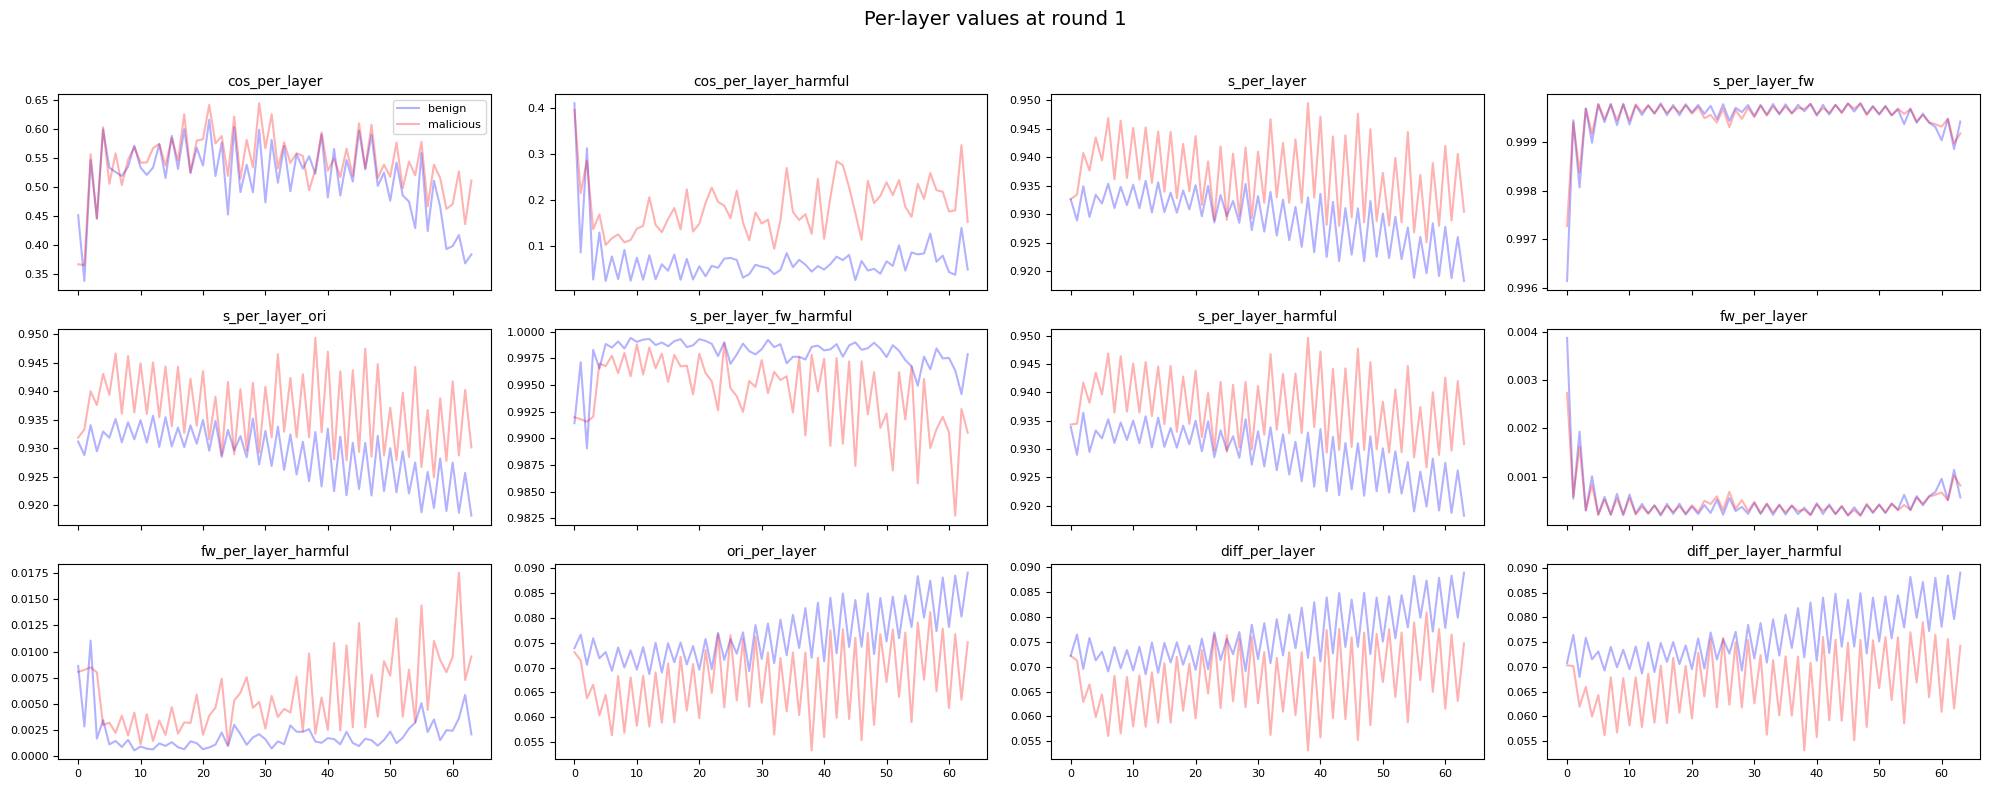

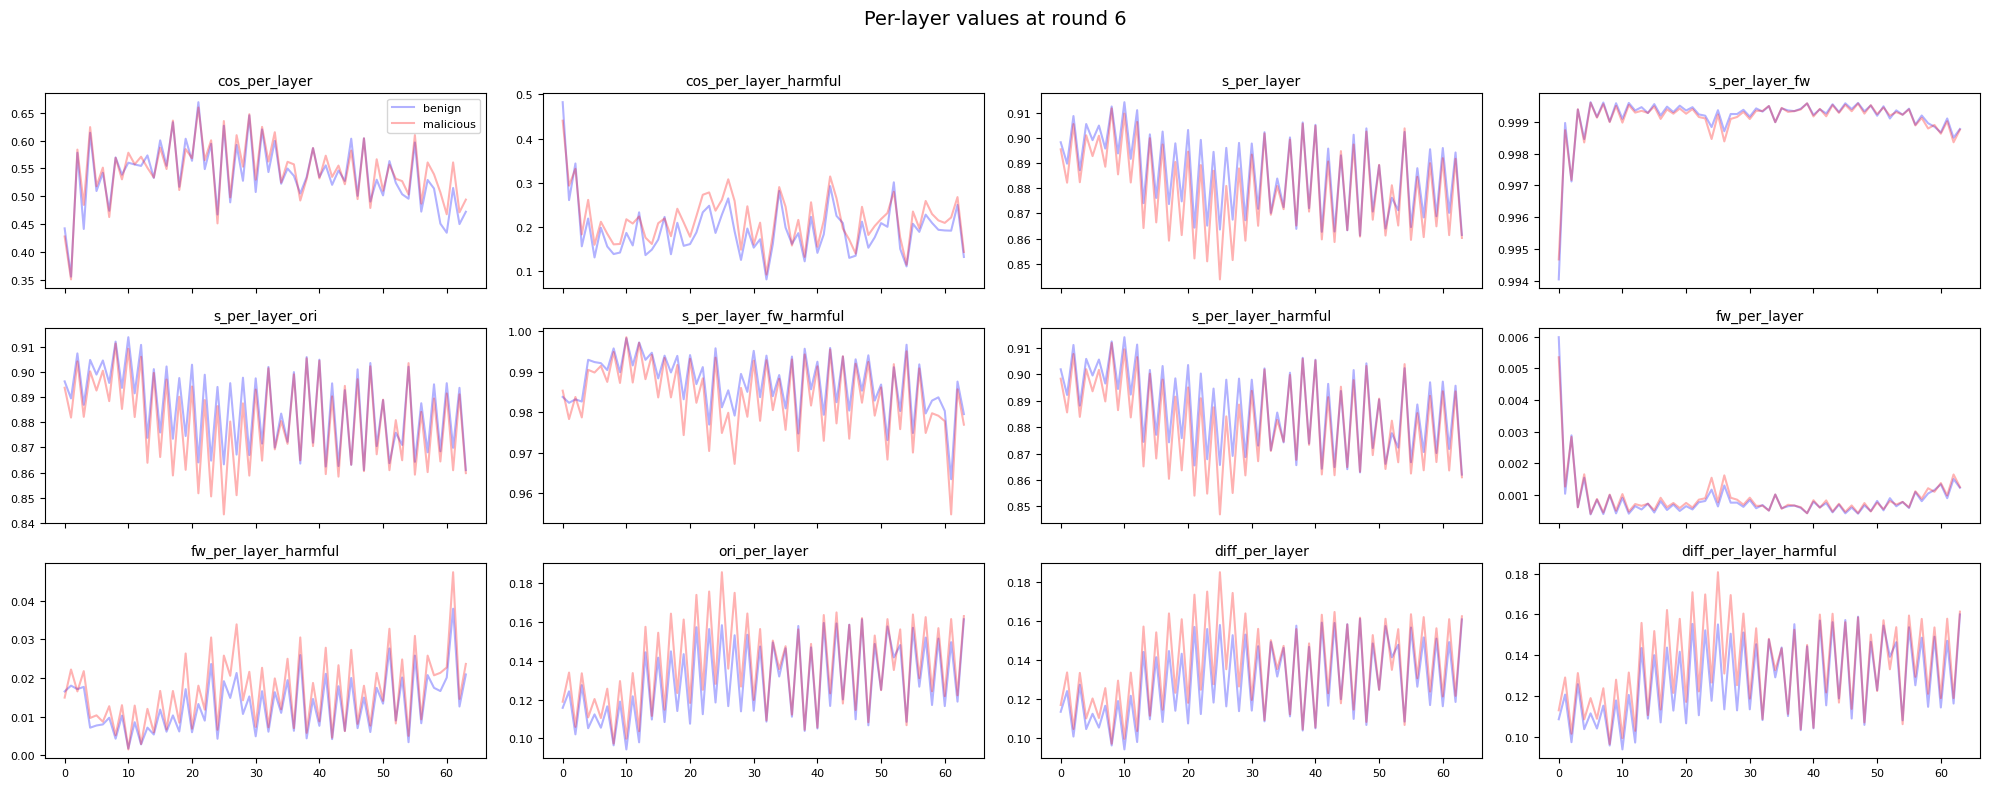

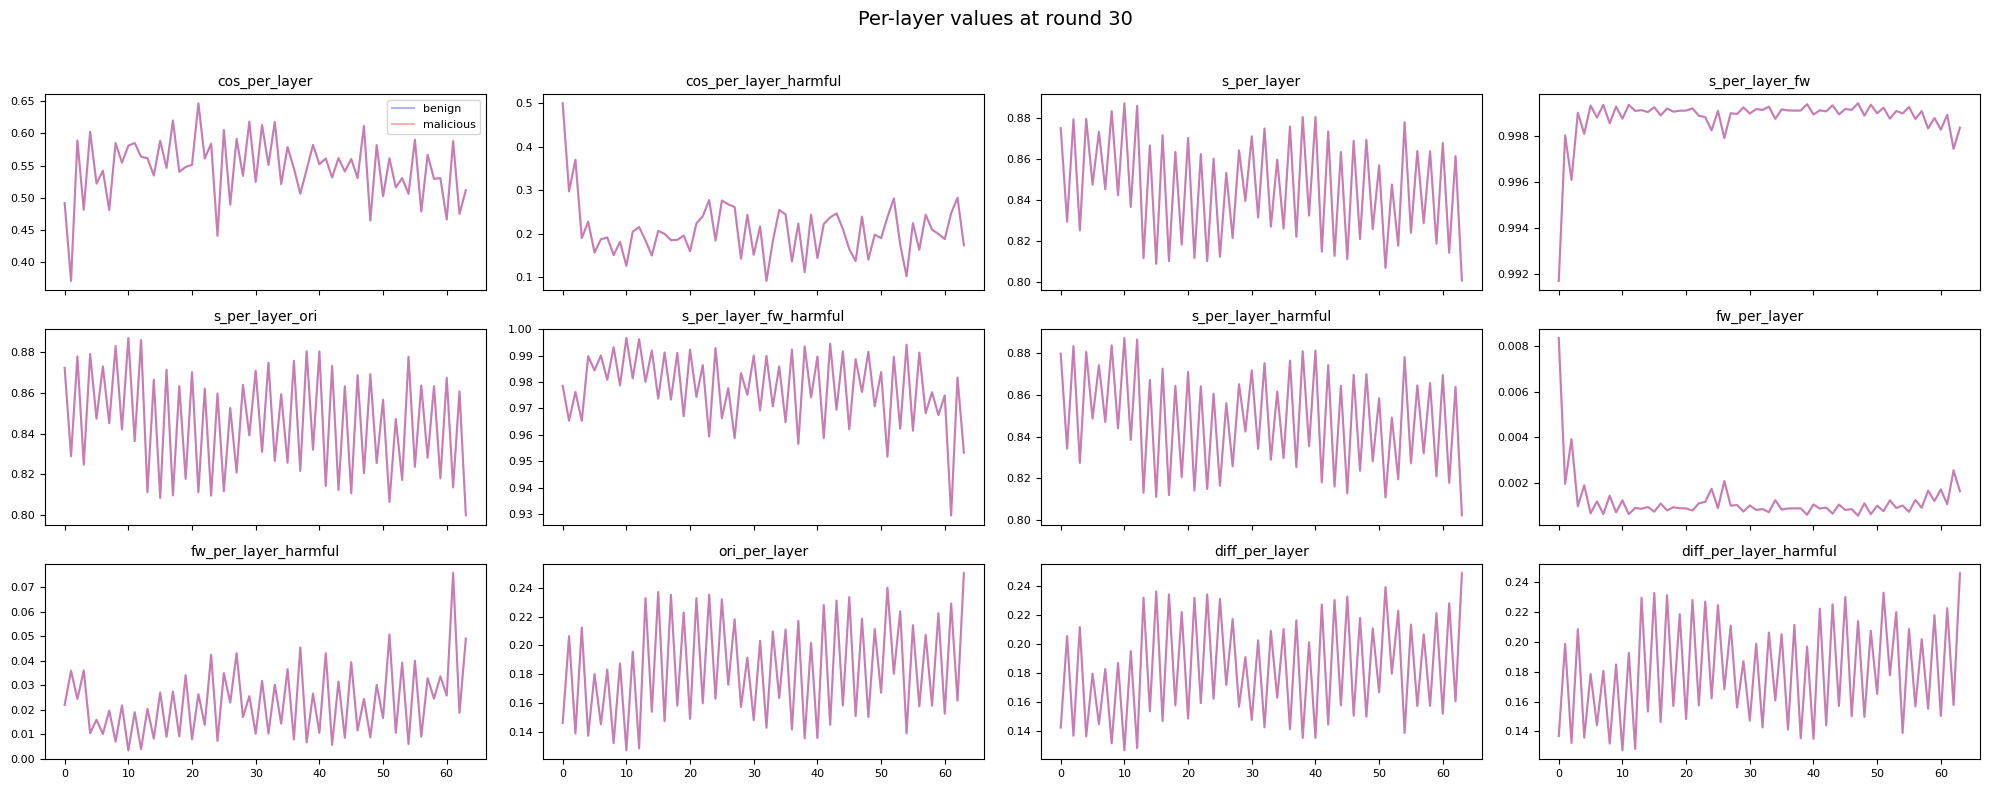

In [37]:
import matplotlib.pyplot as plt

benign_client_id = 0
malicious_client_id = 11

plot_keys = [
    "cos_per_layer",
    "cos_per_layer_harmful",
    "s_per_layer",
    "s_per_layer_fw",
    "s_per_layer_ori",
    "s_per_layer_fw_harmful",
    "s_per_layer_harmful",
    "fw_per_layer",
    "fw_per_layer_harmful",
    "ori_per_layer",
    "diff_per_layer",
    "diff_per_layer_harmful"
]

def plot_round(round_num):
    n_plots = len(plot_keys)
    n_rows, n_cols = 3, 4  # grid shape (2x5 for 10 metrics)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(20, 8),  # adjust if needed
        sharex=True
    )
    axes = axes.ravel()

    for idx, plot_key in enumerate(plot_keys):
        ax = axes[idx]

        benign_values = calculated_safe_lora_data[benign_client_id][round_num][plot_key]
        malicious_values = calculated_safe_lora_data[malicious_client_id][round_num][plot_key]

        ax.plot(range(len(benign_values)), benign_values, color='blue', alpha=0.3, label='benign' if idx == 0 else None)
        ax.plot(range(len(malicious_values)), malicious_values, color='red', alpha=0.3, label='malicious' if idx == 0 else None)

        ax.set_title(plot_key, fontsize=10)
        ax.tick_params(axis='both', labelsize=8)

    # Only first subplot gets the legend, but it applies to all
    axes[0].legend(loc='best', fontsize=8)

    fig.suptitle(f'Per-layer values at round {round_num}', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for suptitle
    plt.show()


# plot for round 1 and 30
plot_round(1)
plot_round(6)
plot_round(30)


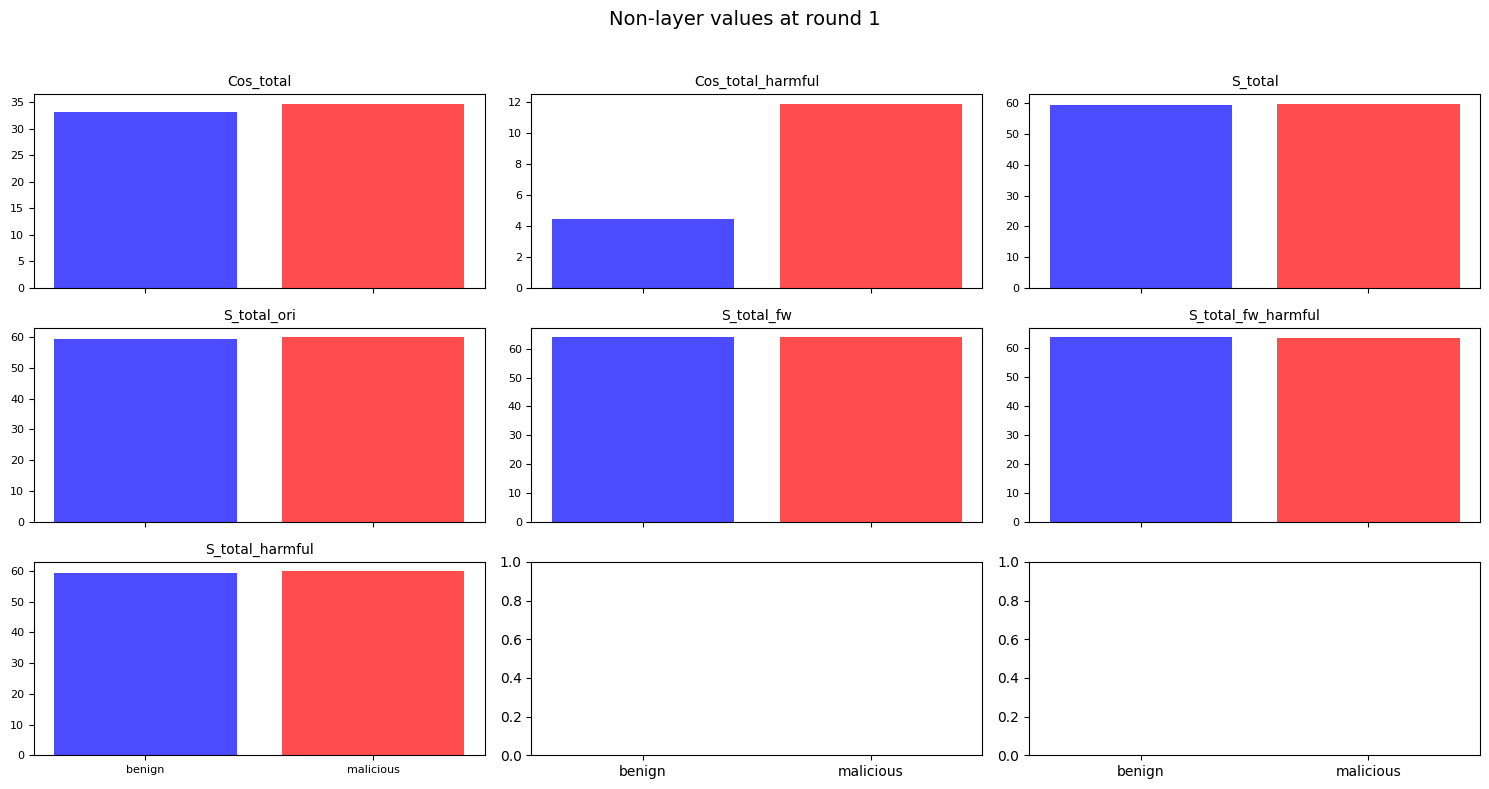

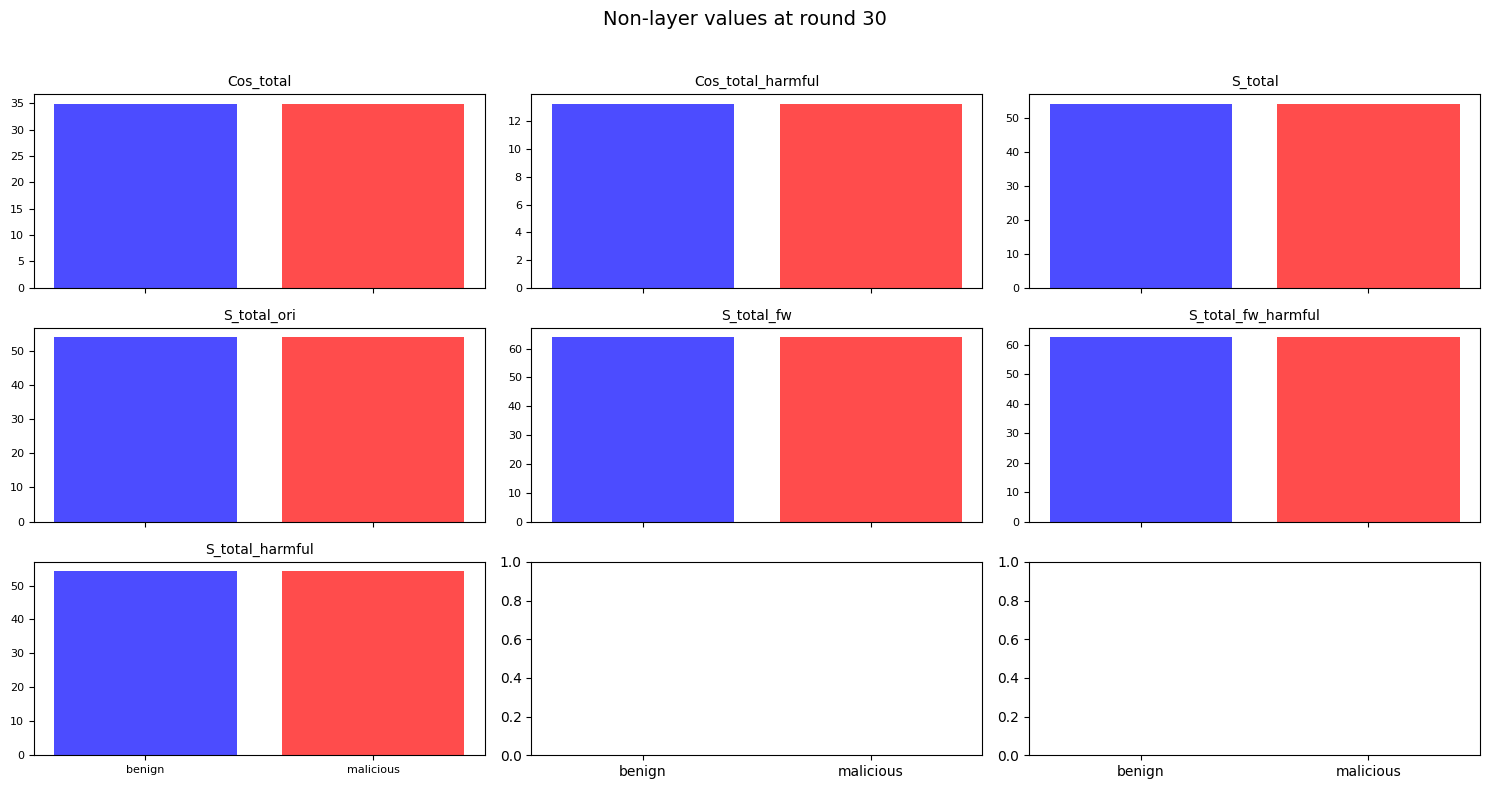

In [32]:
# plot all other non per layer values
plot_keys = [
    "Cos_total",
    "Cos_total_harmful",
    "S_total",
    "S_total_ori",
    "S_total_fw",
    "S_total_fw_harmful",
    "S_total_harmful"
]

def plot_non_layer_round(round):
    n_plots = len(plot_keys)
    n_rows, n_cols = 3, 3  # grid shape (2x3 for 6 metrics)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(15, 8),  # adjust if needed
        sharex=True
    )
    axes = axes.ravel()

    for idx, plot_key in enumerate(plot_keys):
        ax = axes[idx]

        benign_value = calculated_safe_lora_data[benign_client_id][round][plot_key]
        malicious_value = calculated_safe_lora_data[malicious_client_id][round][plot_key]

        ax.bar(['benign', 'malicious'], [benign_value, malicious_value], color=['blue', 'red'], alpha=0.7)

        ax.set_title(plot_key, fontsize=10)
        ax.tick_params(axis='both', labelsize=8)

    fig.suptitle(f'Non-layer values at round {round}', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for suptitle
    plt.show()

# plot for round 1 and 30
plot_non_layer_round(1)
plot_non_layer_round(30)

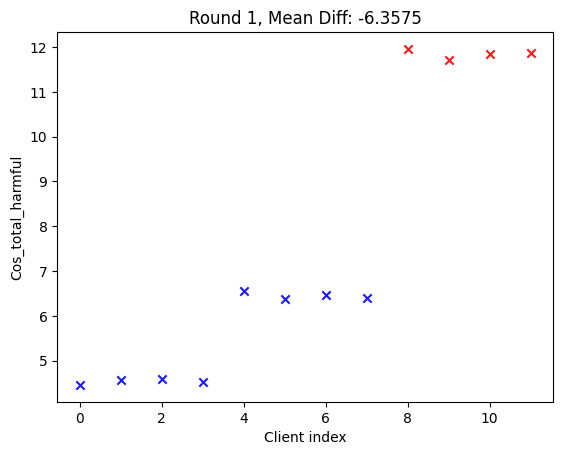

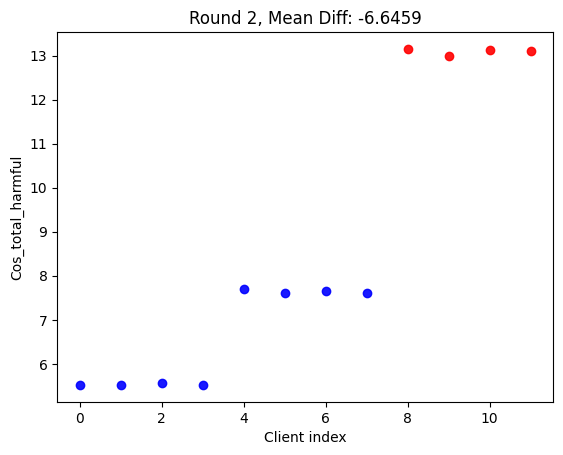

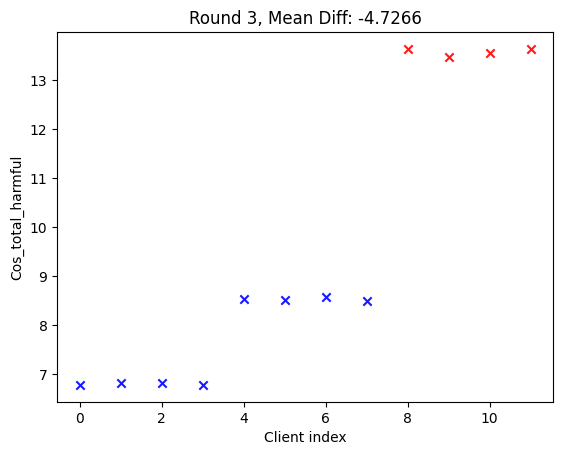

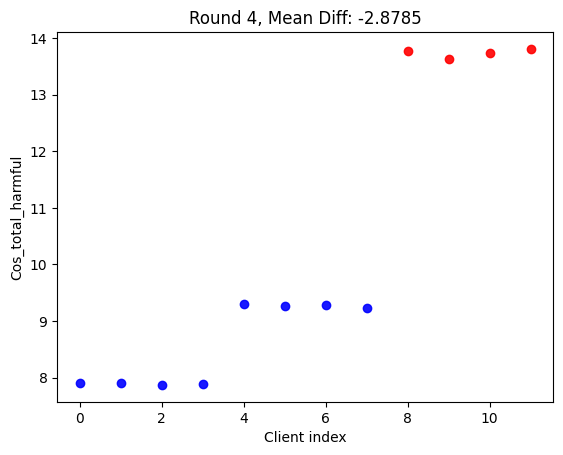

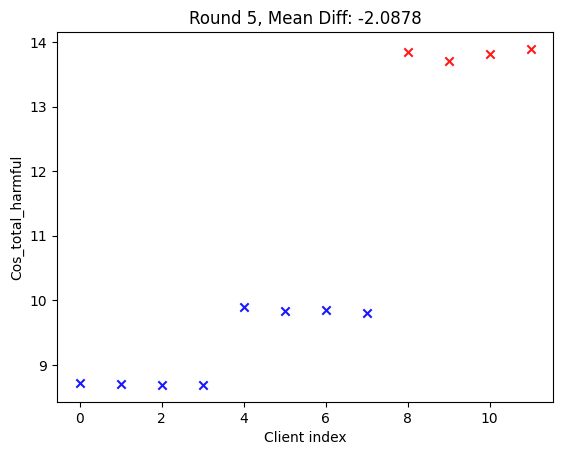

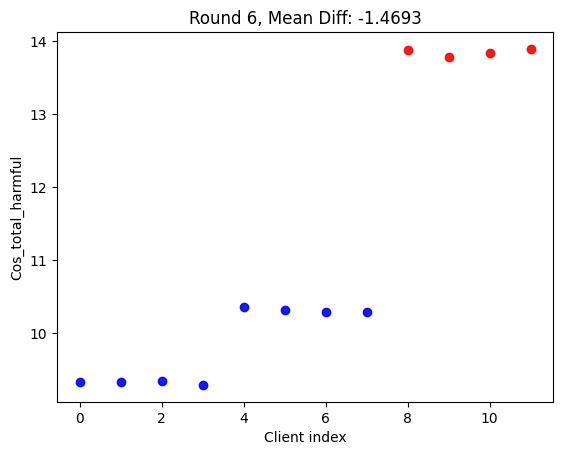

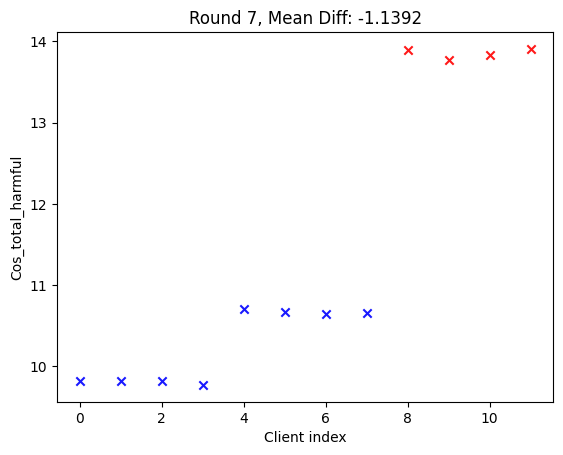

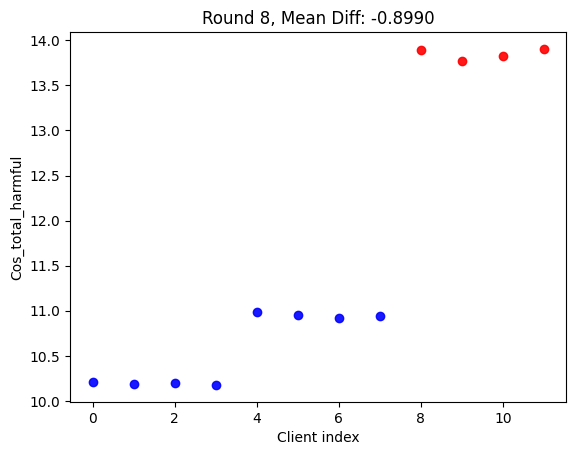

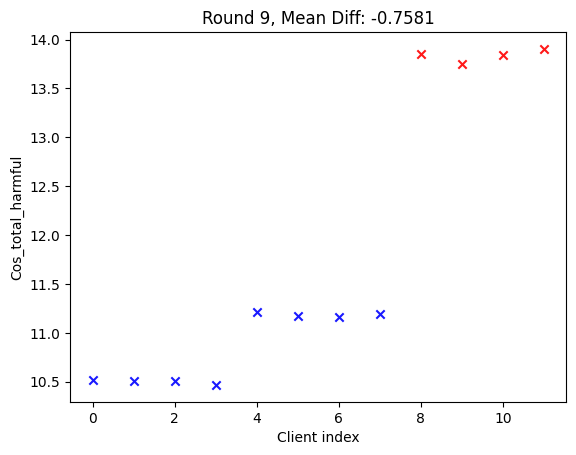

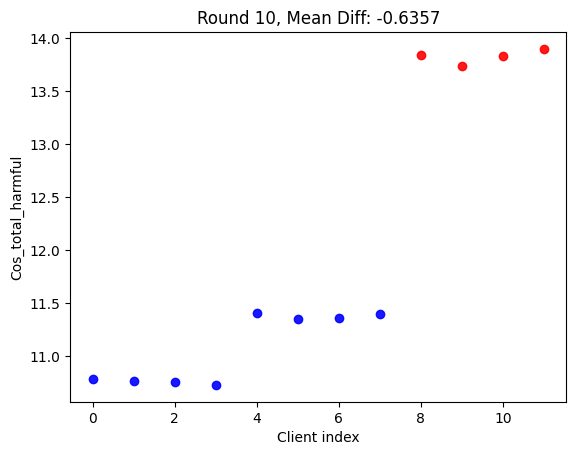

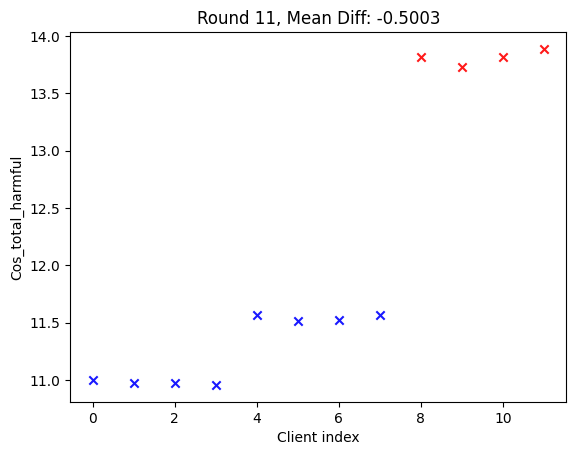

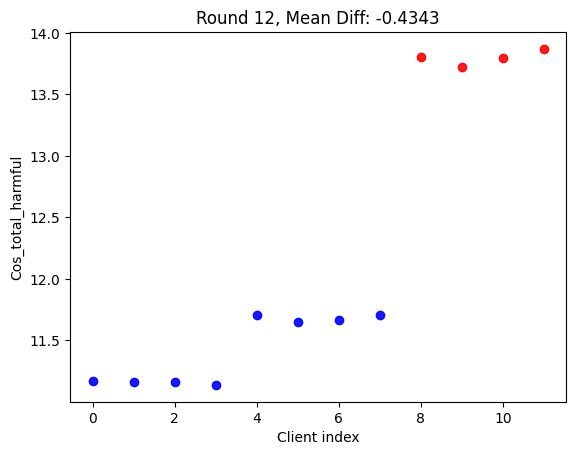

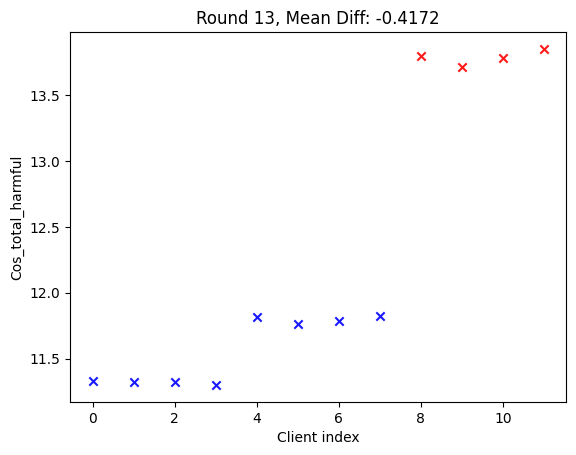

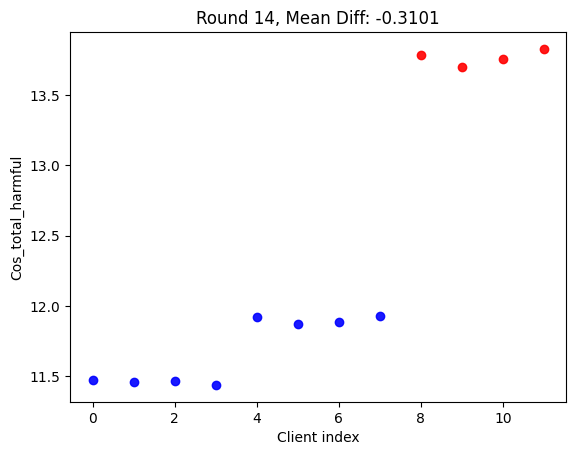

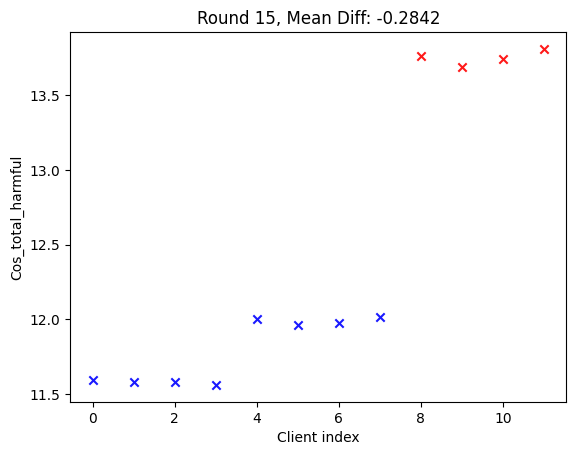

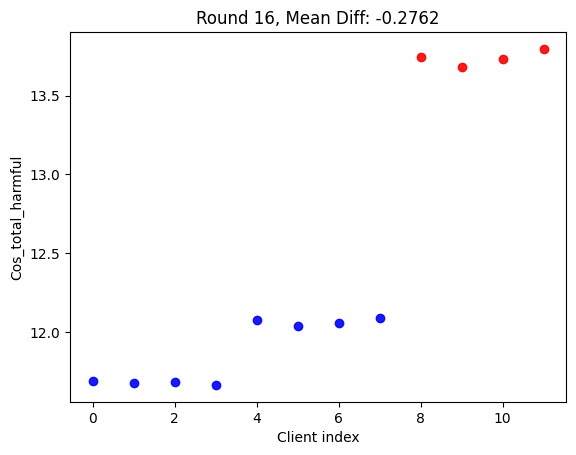

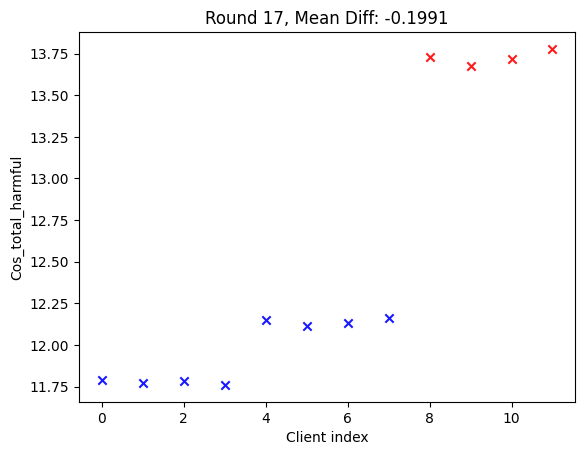

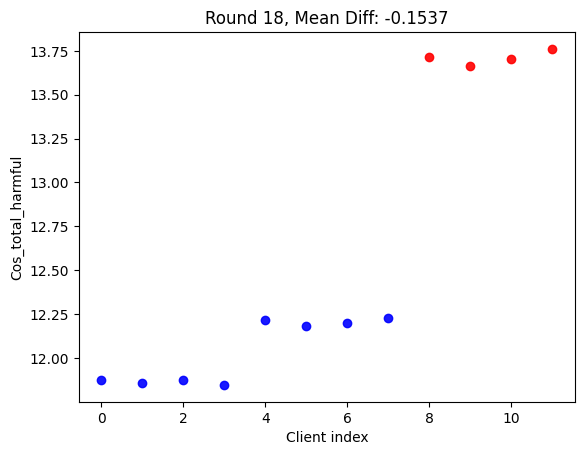

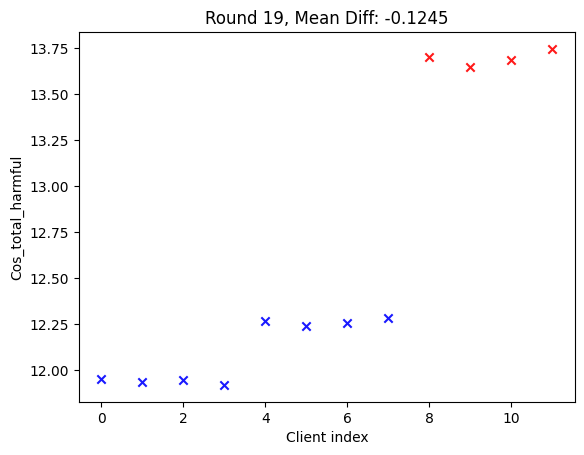

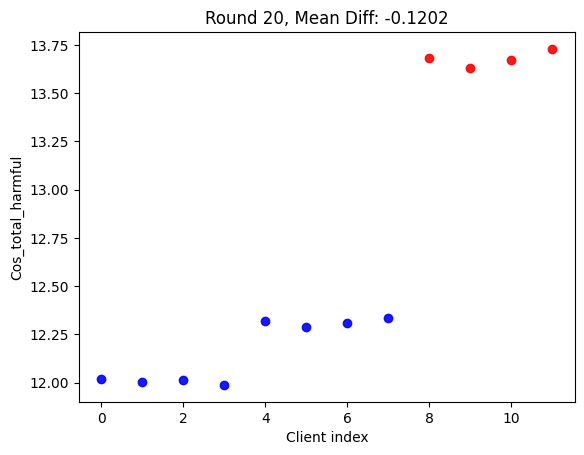

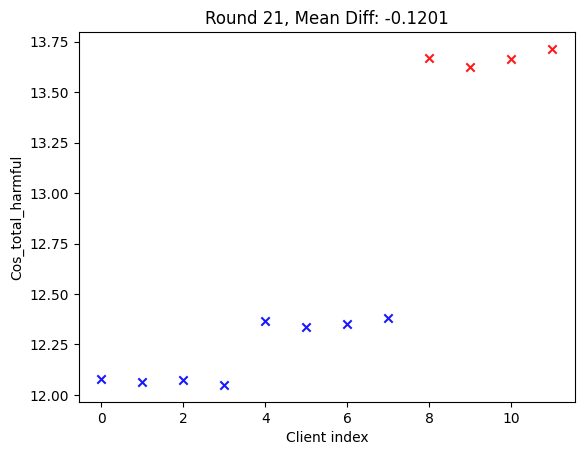

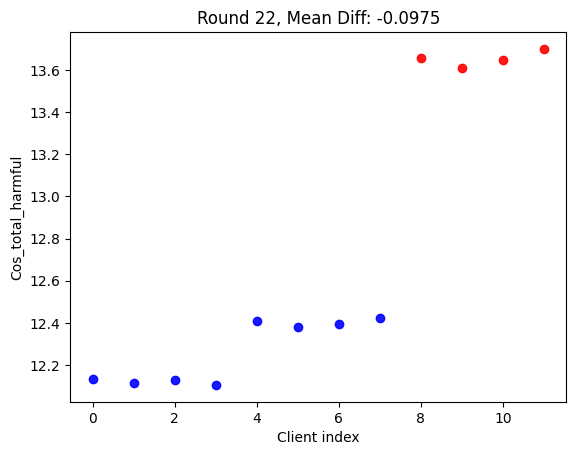

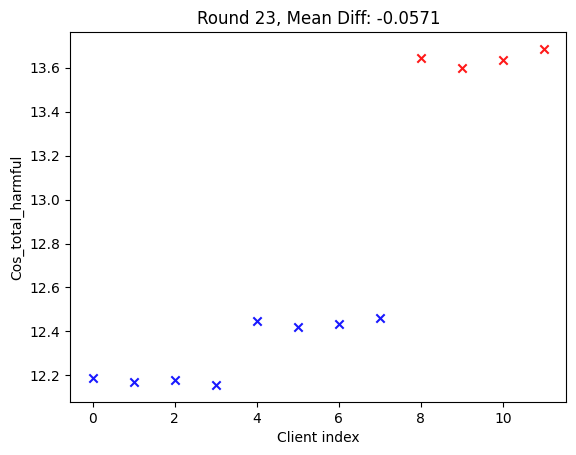

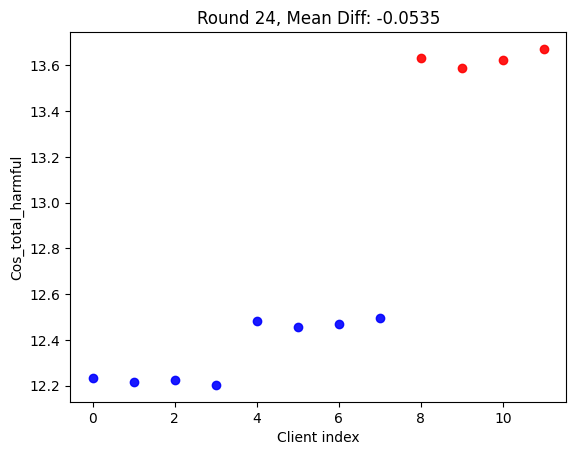

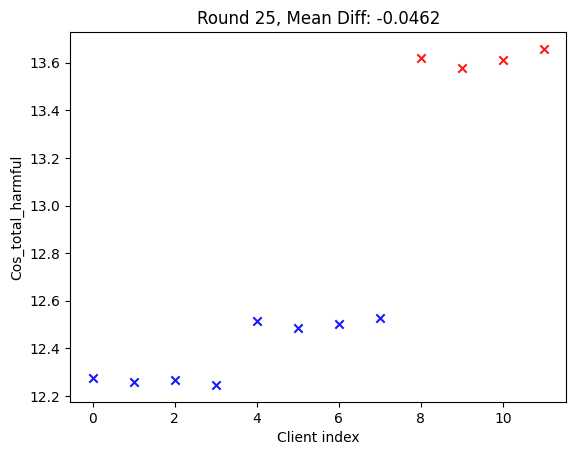

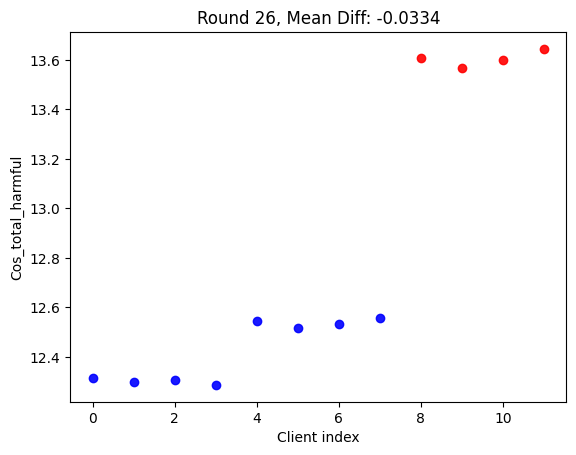

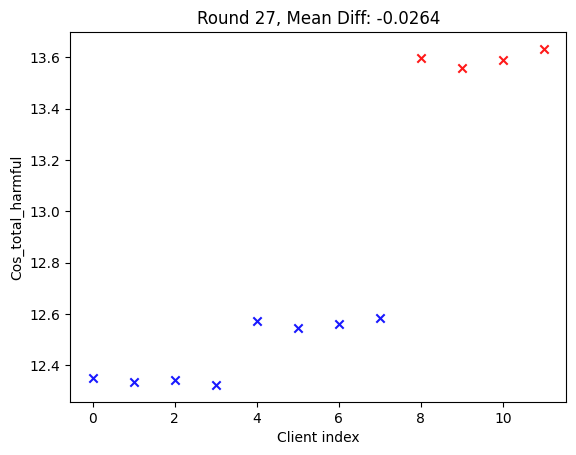

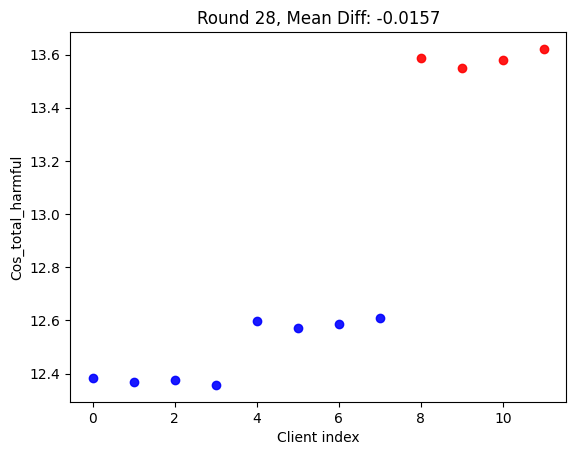

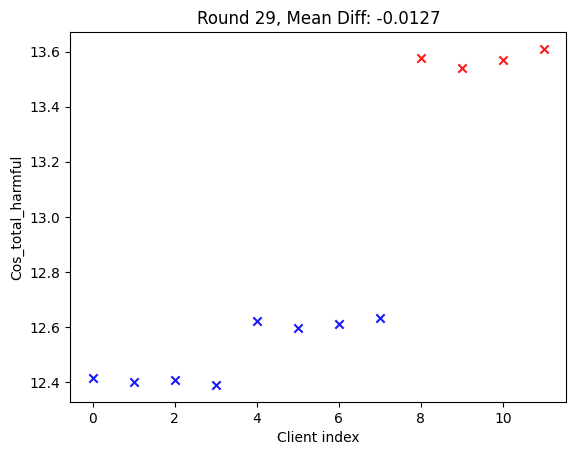

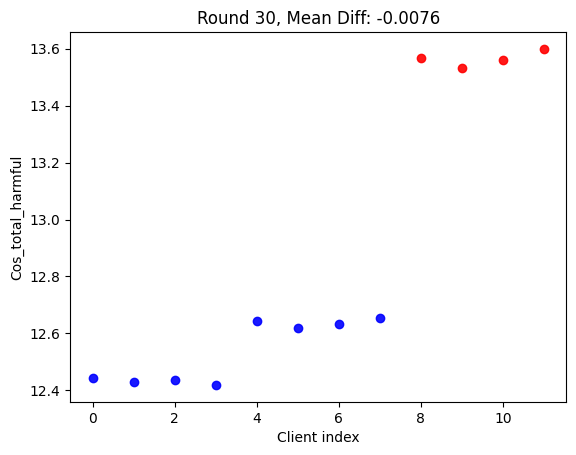

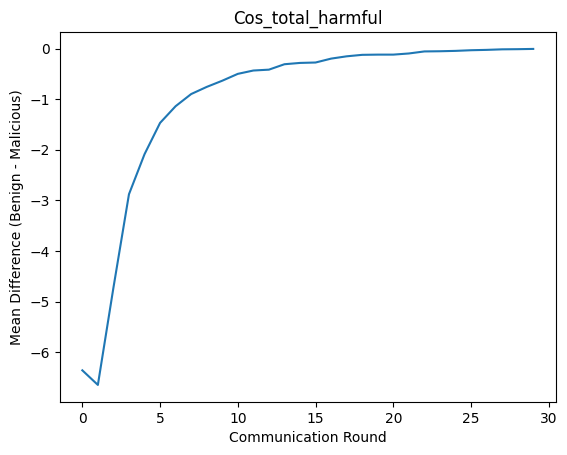

In [ ]:
client_benign_ids = [0,1,2,3,4,5, 6, 7]
client_malicious_ids = [8, 9, 10, 11]
import matplotlib.pyplot as plt
diffs = []
# "S_total": S_total,
#         "S_total_ori": S_total_ori,
#         "S_total_fw": S_total_fw, 
#         "S_total_fw_harmful": S_total_fw_harmful,
#         "S_total_harmful": S_total_harmful

# plot_keys = ['S_total_harmful']
plot_keys = ['Cos_total_harmful']


for plot_key in plot_keys:
    cum_sums = {client: 0.0 for client in range(12)}
    cum_counts = {client: 0   for client in range(12)}
    for round in range(1, 31):
        if round%2 == 0:
            marker = 'o'
        else:
            marker = 'x'

        cos_per_layer = {client: sum(calculated_safe_lora_data[client][round]['cos_per_layer']) for client in range(0, 12)}
        try:
            S_total = {client: calculated_safe_lora_data[client][round][plot_key] for client in range(0, 12)}
            # cos_per_layer = {client: calculated_safe_lora_data[client][round]['cos_per_layer'].sum() for client in range(0, 10)}
        except:
            
            print("continued")
            continue
        # for key, value in cos_per_layer.items():

        for client, val in S_total.items():
            cum_sums[client] += val
            cum_counts[client] += 1

        # cumulative average up to this round
        # S_total_cumavg = {
        #     client: (cum_sums[client] / cum_counts[client])
        #     for client in S_total.keys() if cum_counts[client] > 0
        # }

        for key, value in S_total.items():
            plt.scatter(key, value, color='blue' if int(key) in client_benign_ids else 'red', alpha=0.9, marker=marker)


        # print difference between mean of benign and malicious clients
        benign_values = [v for k, v in S_total.items() if int(k) in client_benign_ids]
        malicious_values = [v for k, v in S_total.items() if int(k) in client_malicious_ids]
        benign_mean = np.mean(benign_values)
        malicious_mean = np.mean(malicious_values)
        diff = benign_mean - malicious_mean
        diffs.append(diff)

        plt.title(f'Round {round}, Mean Diff: {diff:.4f}')
        plt.ylabel(plot_key)
        plt.xlabel("Client index")
        plt.show()

    plt.plot(list(range(len(diffs))), diffs)
    plt.xlabel('Communication Round')
    plt.ylabel('Mean Difference (Benign - Malicious)')
    plt.title(plot_key)
    plt.show()
    diffs = []

        # for key, value in cos_per_layer.items():
        #     plt.plot(list(range(len(value))), value, color='green' if int(key) in client_benign_ids else 'red')
            
    # plt.title(f'Round {round}, Mean Diff: {diff:.4f}')
    # plt.show()

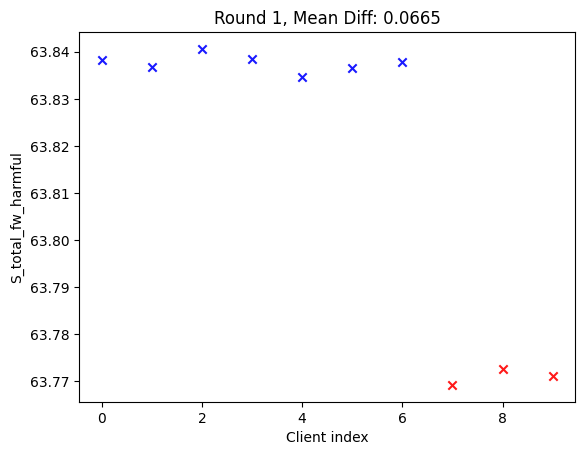

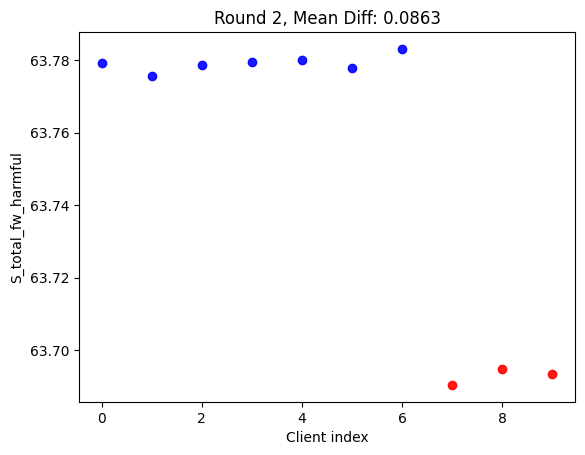

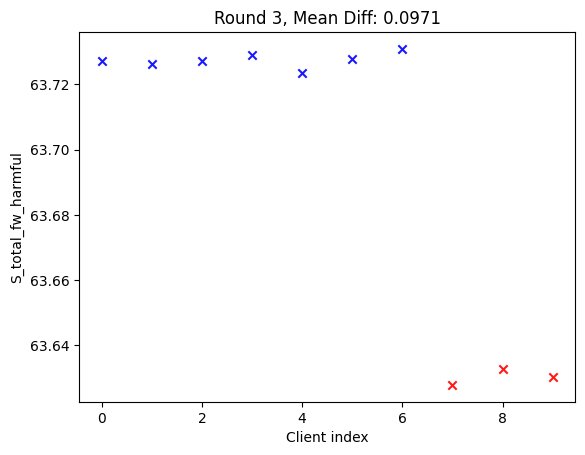

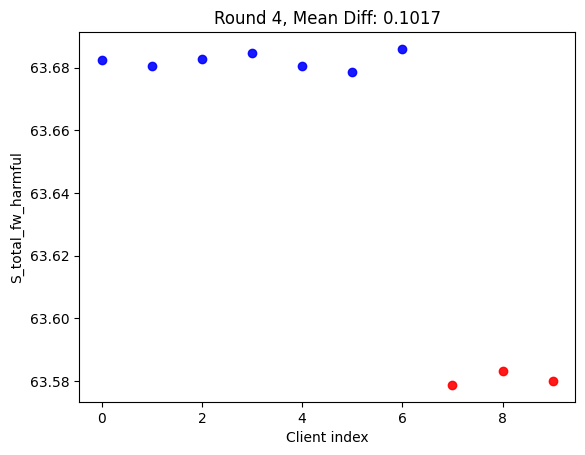

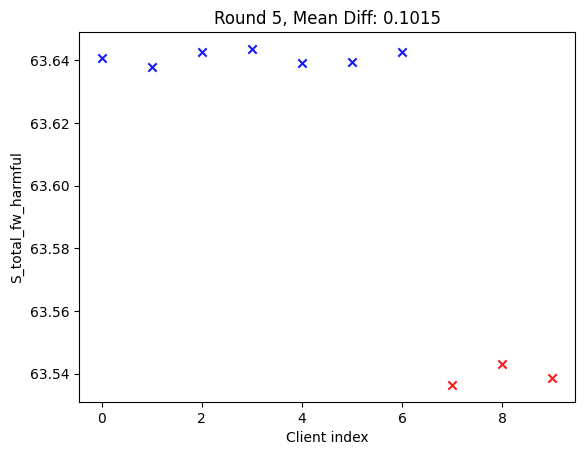

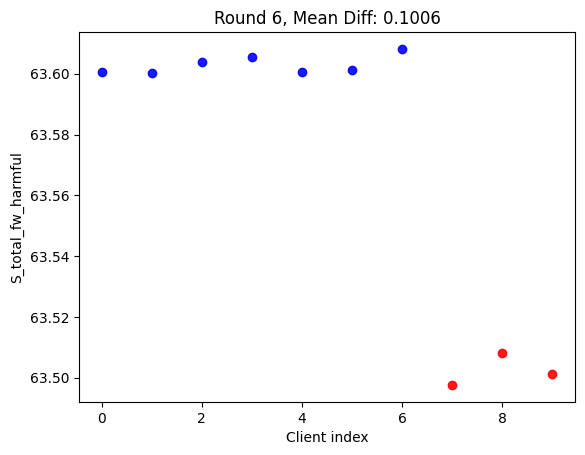

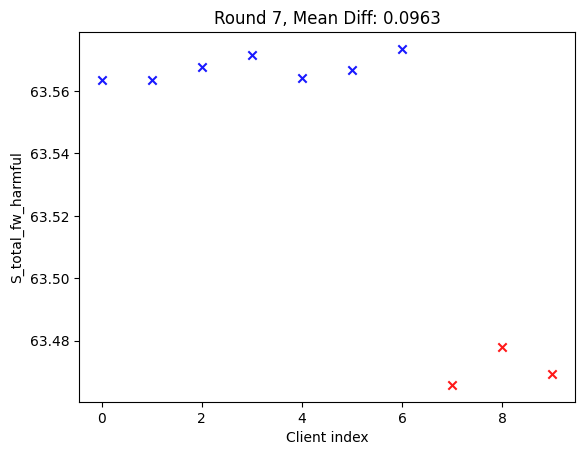

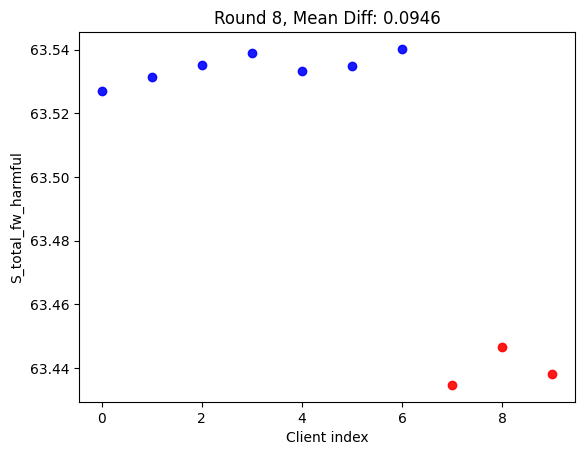

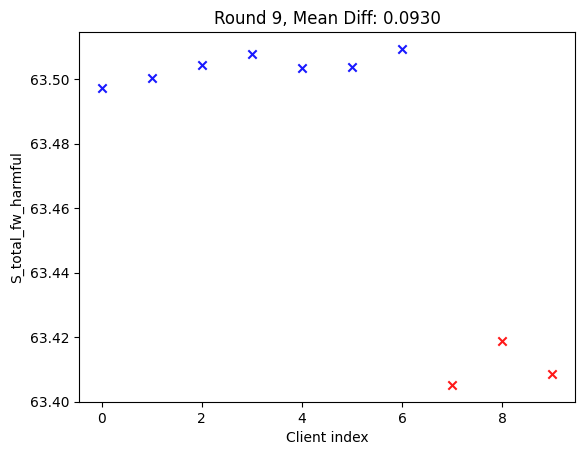

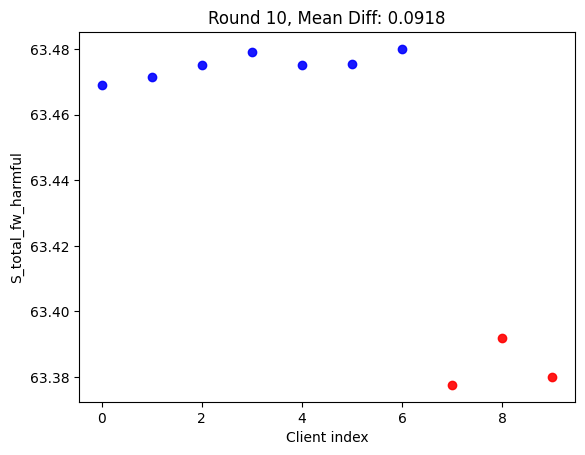

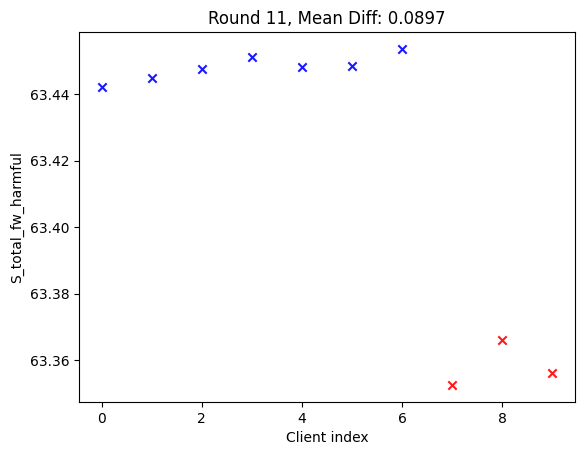

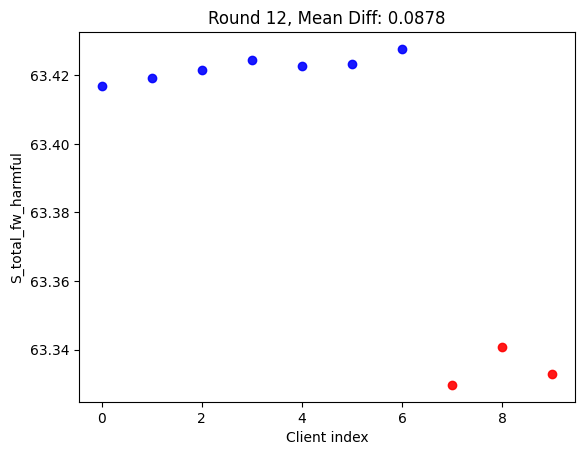

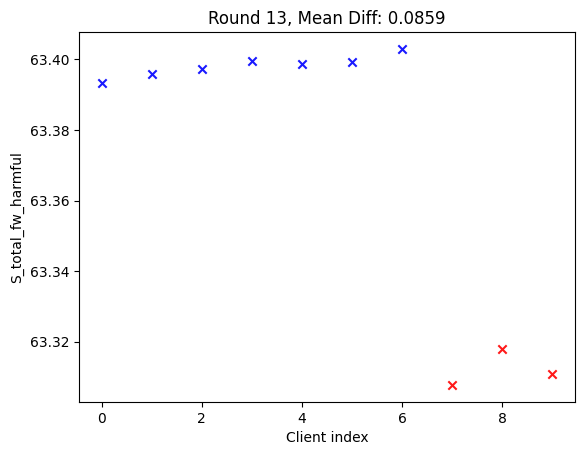

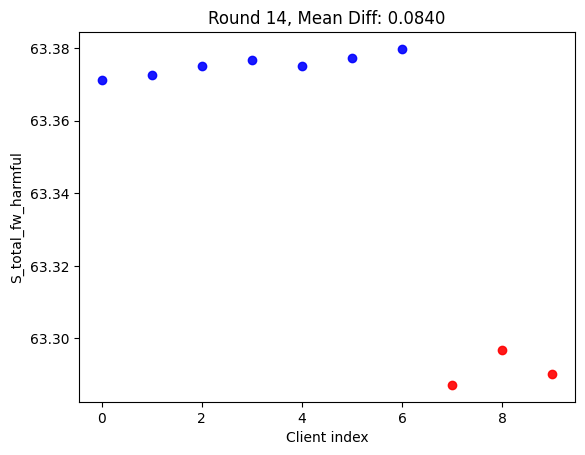

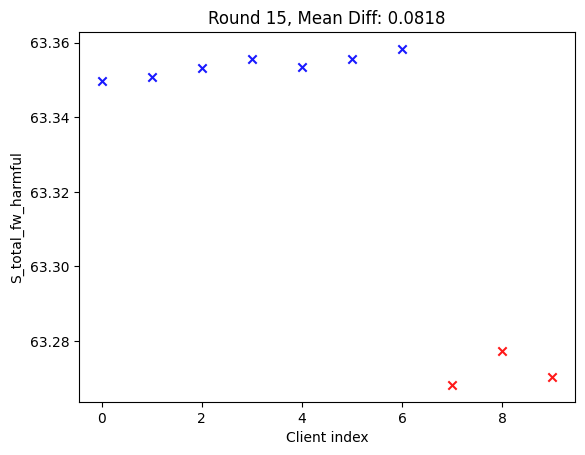

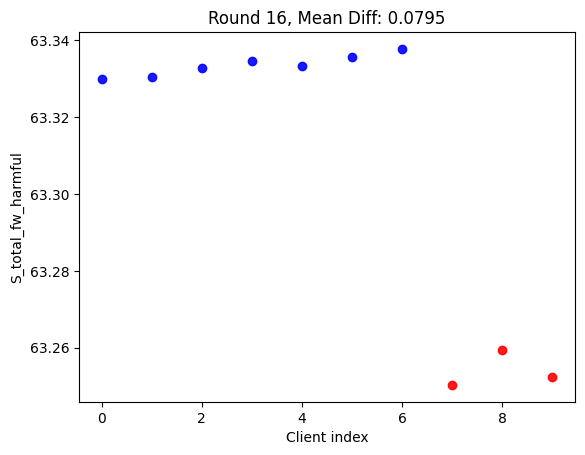

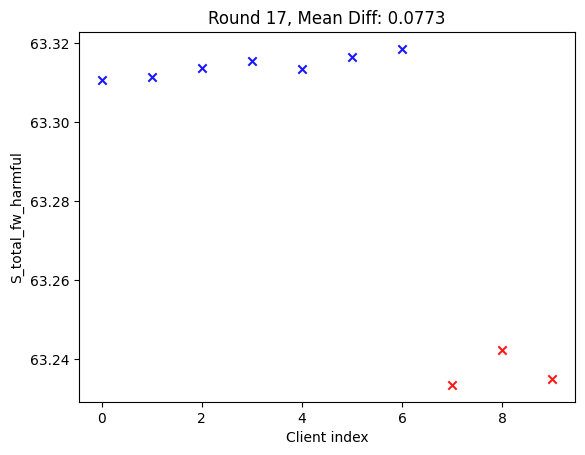

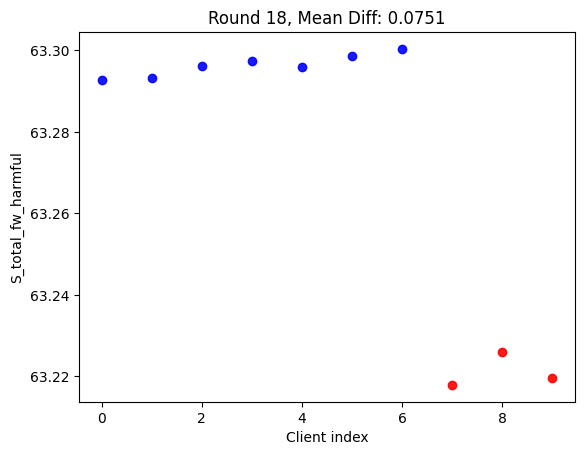

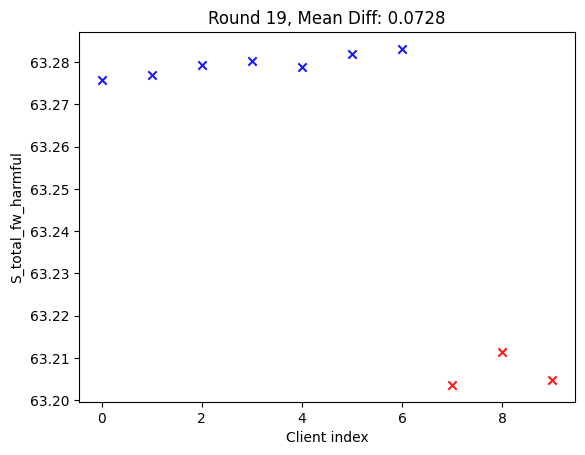

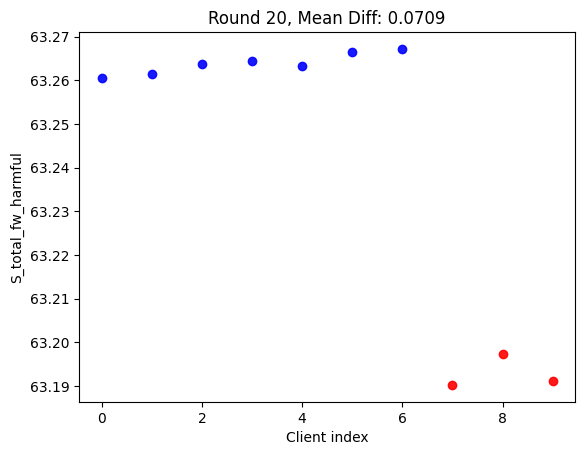

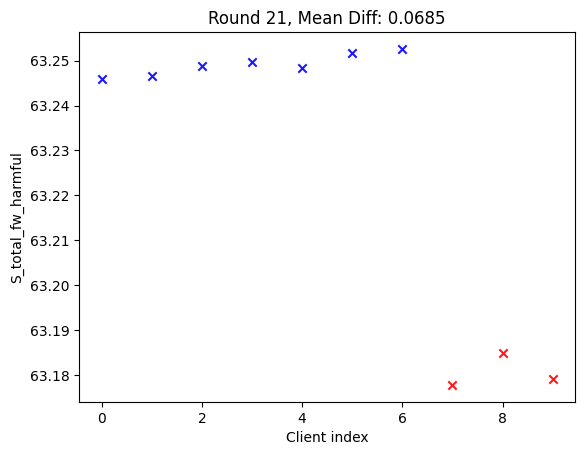

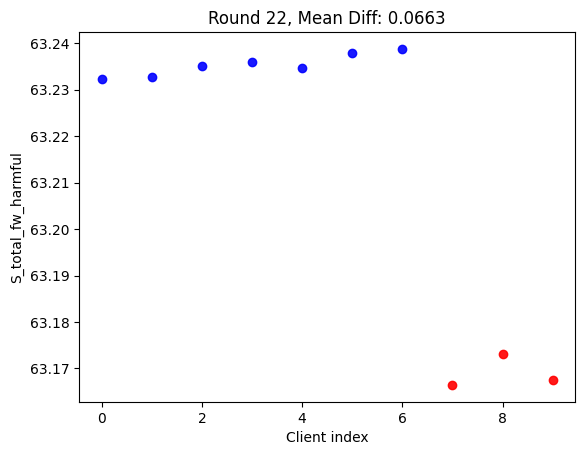

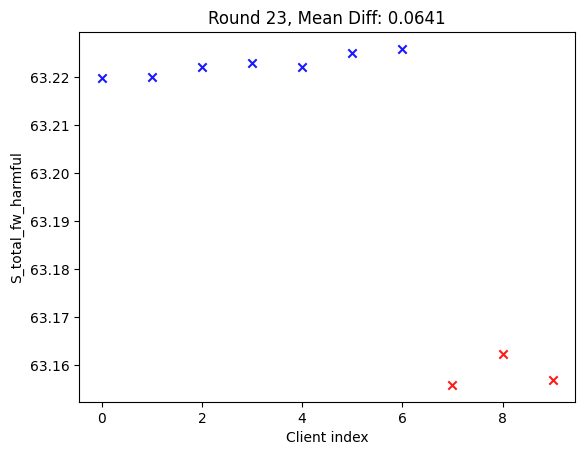

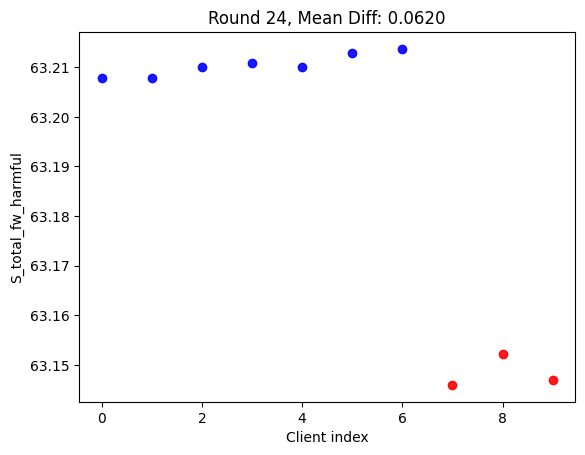

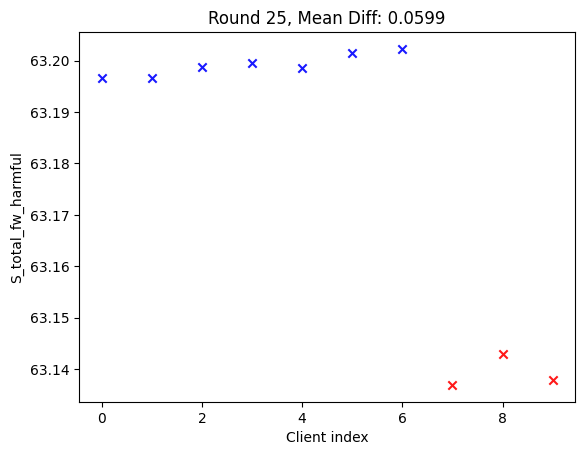

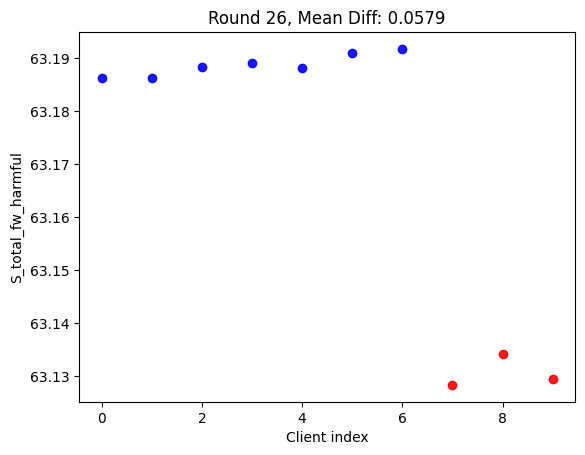

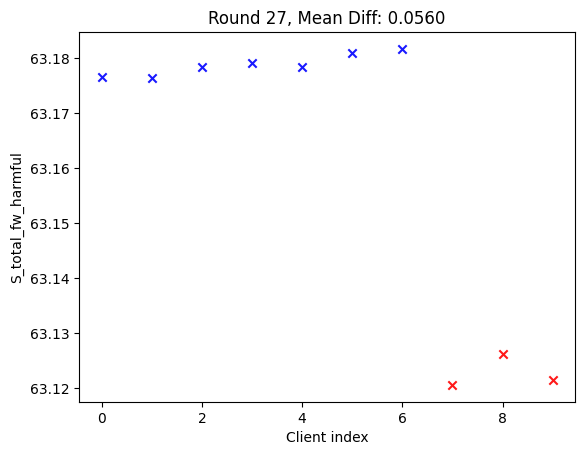

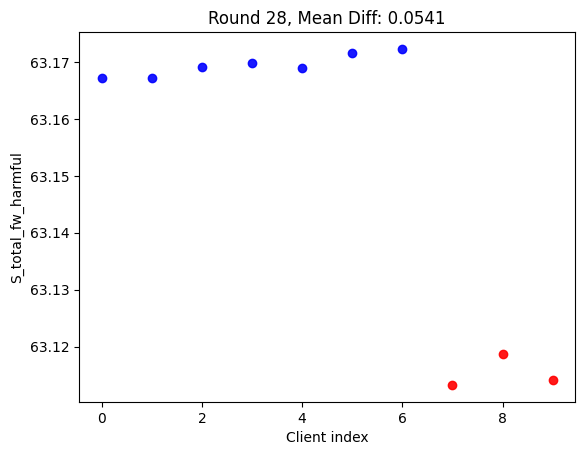

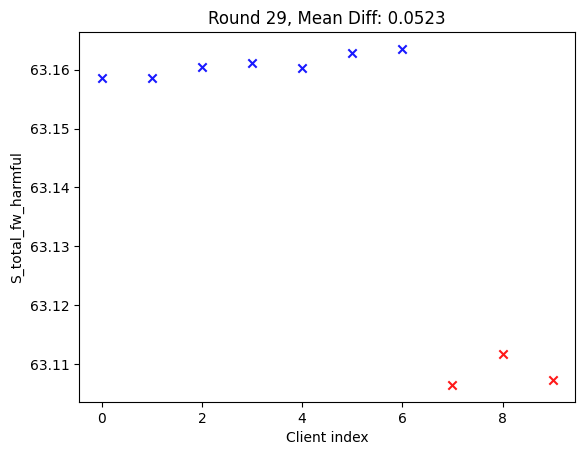

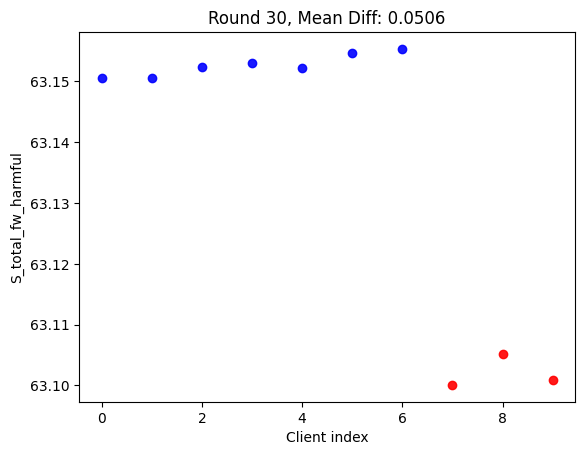

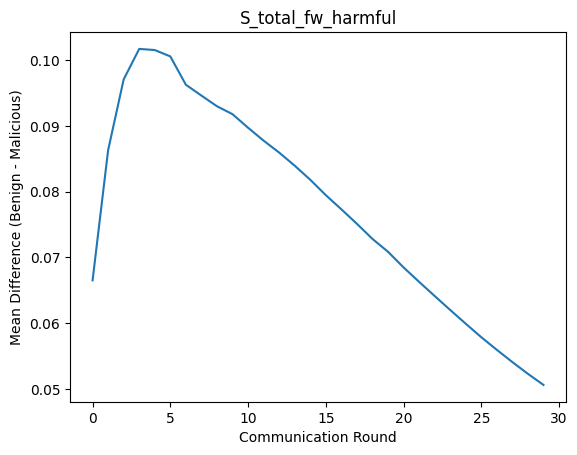

In [8]:
client_benign_ids = [0,1,2,3,4,5, 6]
client_malicious_ids = [7, 8,9]
import matplotlib.pyplot as plt
diffs = []
# "S_total": S_total,
#         "S_total_ori": S_total_ori,
#         "S_total_fw": S_total_fw, 
#         "S_total_fw_harmful": S_total_fw_harmful,
#         "S_total_harmful": S_total_harmful

plot_keys = ['S_total_fw_harmful']

for plot_key in plot_keys:
    cum_sums = {client: 0.0 for client in range(10)}
    cum_counts = {client: 0   for client in range(10)}
    for round in range(1, 31):
        if round%2 == 0:
            marker = 'o'
        else:
            marker = 'x'

        cos_per_layer = {client: sum(calculated_safe_lora_data[client][round]['cos_per_layer']) for client in range(0, 10)}
        try:
            S_total = {client: calculated_safe_lora_data[client][round][plot_key] for client in range(0, 10)}
            # cos_per_layer = {client: calculated_safe_lora_data[client][round]['cos_per_layer'].sum() for client in range(0, 10)}
        except:
            
            print("continued")
            continue
        # for key, value in cos_per_layer.items():

        for client, val in S_total.items():
            cum_sums[client] += val
            cum_counts[client] += 1

        # cumulative average up to this round
        S_total_cumavg = {
            client: (cum_sums[client] / cum_counts[client])
            for client in S_total.keys() if cum_counts[client] > 0
        }

        for key, value in S_total_cumavg.items():
            plt.scatter(key, value, color='blue' if int(key) in client_benign_ids else 'red', alpha=0.9, marker=marker)


        # print difference between mean of benign and malicious clients
        benign_values = [v for k, v in S_total_cumavg.items() if int(k) in client_benign_ids]
        malicious_values = [v for k, v in S_total_cumavg.items() if int(k) in client_malicious_ids]
        benign_mean = np.mean(benign_values)
        malicious_mean = np.mean(malicious_values)
        diff = benign_mean - malicious_mean
        diffs.append(diff)

        plt.title(f'Round {round}, Mean Diff: {diff:.4f}')
        plt.ylabel(plot_key)
        plt.xlabel("Client index")
        plt.show()

    plt.plot(list(range(len(diffs))), diffs)
    plt.xlabel('Communication Round')
    plt.ylabel('Mean Difference (Benign - Malicious)')
    plt.title(plot_key)
    plt.show()
    diffs = []

        # for key, value in cos_per_layer.items():
        #     plt.plot(list(range(len(value))), value, color='green' if int(key) in client_benign_ids else 'red')
            
    # plt.title(f'Round {round}, Mean Diff: {diff:.4f}')
    # plt.show()

In [9]:
# pkl_root = '/scratch/ps9044/fedllm/barebones/WildChat7_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251106124747'
# pkl_root = '/scratch/ps9044/fedllm/barebones/WildChat7_lmsys3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109213209'
# pkl_root = '/scratch/ps9044/fedllm/barebones/WildChat2_lmsys2_dromedary2_BeaverTails2_MaliciousGen2_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109200519'
pkl_root = '/shared/rc/llm-degredation/fedllm/barebones/sst27_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251117184220'
# pkl_root = '/shared/rc/llm-degredation/fedllm/barebones/gsm8k7_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251117190648'
import os
import pickle
import numpy as np
# pkl_root = '/scratch/ps9044/fedllm/safelora_maliciousgen_llama27bchat/MaliciousGen1__0_1000_fedavg_c1s1_i10_b16a1_l512_r32a64_20251113142234'
# pkl_root = '/scratch/ps9044/fedllm/barebones/WildChat3_dromedary4_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251113002455'
# pkl_root = '/scratch/ps9044/fedllm/barebones/dromedary5_BeaverTails5_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251113074941'
# pkl_root = '/scratch/ps9044/fedllm/barebones/dromedary7_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251111000918'
# import pickle
# for round in range(1, 31):
#     file_name = os.path.join(pkl_root, f'round_{round}_clean.pkl')
#     if not os.path.exists(file_name):
#         continue
#     with open(file_name, 'rb') as f:
#         data = pickle.load(f)
   
#     # pickle.dump({
#     #     "round_idx": round_idx,
#     #     "clients": clients_this_round,
#     #     "local_dict_list": local_dict_list,
#     #     "global_dict": global_dict,
#     #     "fed_args": fed_args,
#     #     "sample_num_list": sample_num_list,
#     #     "base_model_path": script_args.model_name_or_path
#     # }, f)

#     global_dict = data['global_dict']
#     local_dict_list = data['local_dict_list']
#     clients_this_round = data['clients']
#     for client in clients_this_round:
#         local_dict = local_dict_list[client]
#         # print(local_dict)
#         safe_lora_data = projected_weighted(local_dict, project_matrix)
#         print(f'Round {round} Client {client} S_total: {safe_lora_data["S_total"]} Cosine per layer: {safe_lora_data["cos_per_layer"]}')
#     # print('-----------------------------------') 
#         break   


def consider_past_history(upto_current_local_dict, current_local_dict, global_dict, alpha=0.5):
    for key in upto_current_local_dict.keys():
        upto_current_local_dict[key] += current_local_dict[key] - global_dict[key]
    return upto_current_local_dict


calculated_safe_lora_data = {}
for client in range(0, 10):
    calculated_safe_lora_data[client] = {}
    for round in range(1, 31):
        calculated_safe_lora_data[client][round] = {}
        file_name = os.path.join(pkl_root, f'round_{round}_clean.pkl')
        if not os.path.exists(file_name):
            file_name = os.path.join(pkl_root, f'round_{round}.pkl')
        if not os.path.exists(file_name):
            continue
        with open(file_name, 'rb') as f:
            data = pickle.load(f)



        global_dict = data['global_dict']
        local_dict_list = data['local_dict_list']
        clients_this_round = data['clients']
        if client in clients_this_round:
            local_dict = local_dict_list[client]
            final_local_dict = data['local_dict_list'][client]
            # if round == 1:
            #     initial_local_dict = data['local_dict_list'][client]
            #     # first_key = list(initial_local_dict.keys())[0]
            #     final_local_dict = initial_local_dict 
            #     # print(initial_local_dict[first_key].sum().item())
            # else:
            #     final_local_dict = consider_past_history(final_local_dict, local_dict, global_dict)
            # # print(initial_local_dict[first_key].sum().item())
            # # print(local_dict)
            safe_lora_data = projected_weighted(final_local_dict, project_matrix_base, project_matrix_harmful)
            print(f'Round {round} Client {client} S_total: {safe_lora_data["S_total"]} Cosine per layer: {safe_lora_data["cos_per_layer"]}')
            calculated_safe_lora_data[client][round] = safe_lora_data


Round 1 Client 0 S_total: 59.66253317 Cosine per layer: [0.41792, 0.33021, 0.53223, 0.47825, 0.60284, 0.53135, 0.54236, 0.55909, 0.56111, 0.56419, 0.55192, 0.53691, 0.55045, 0.56539, 0.53844, 0.57319, 0.55215, 0.56799, 0.53768, 0.56728, 0.5656, 0.59835, 0.53321, 0.5788, 0.48304, 0.60827, 0.4872, 0.55456, 0.5154, 0.60143, 0.54416, 0.58787, 0.51794, 0.59967, 0.5075, 0.56269, 0.53417, 0.58157, 0.53067, 0.58143, 0.52806, 0.58077, 0.52178, 0.55614, 0.5186, 0.54885, 0.54219, 0.59787, 0.53791, 0.56723, 0.51902, 0.54733, 0.52076, 0.55217, 0.47816, 0.52389, 0.45104, 0.53597, 0.49876, 0.40855, 0.45958, 0.50869, 0.40134, 0.45297]
Round 2 Client 0 S_total: 59.55115453 Cosine per layer: [0.44035, 0.32664, 0.54213, 0.4628, 0.60203, 0.53843, 0.53352, 0.56151, 0.56179, 0.57691, 0.55804, 0.54086, 0.53838, 0.56431, 0.54015, 0.58205, 0.5663, 0.58713, 0.54223, 0.58997, 0.5648, 0.61492, 0.53346, 0.60064, 0.49248, 0.61974, 0.49407, 0.56947, 0.51661, 0.62206, 0.56206, 0.60651, 0.52763, 0.59927, 0.49679, 0.57

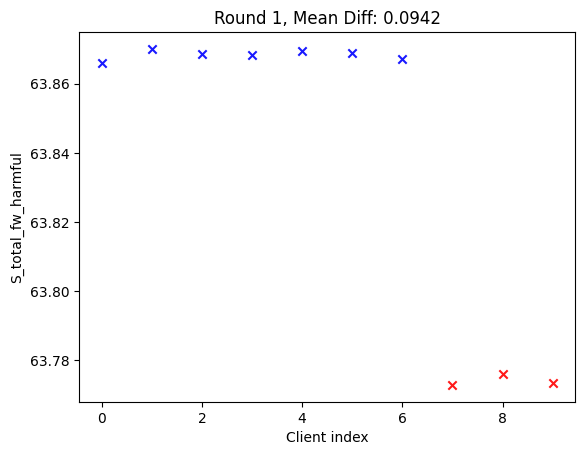

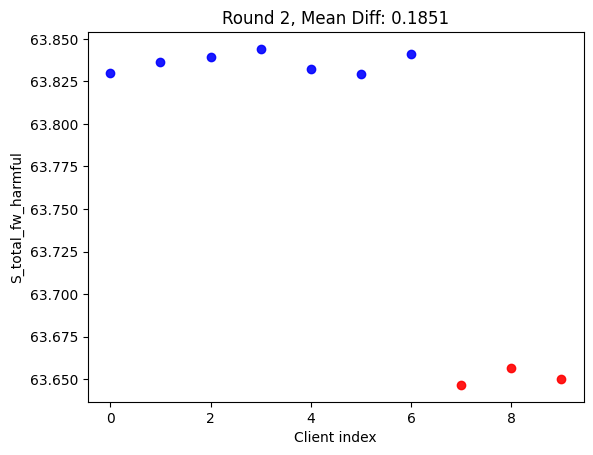

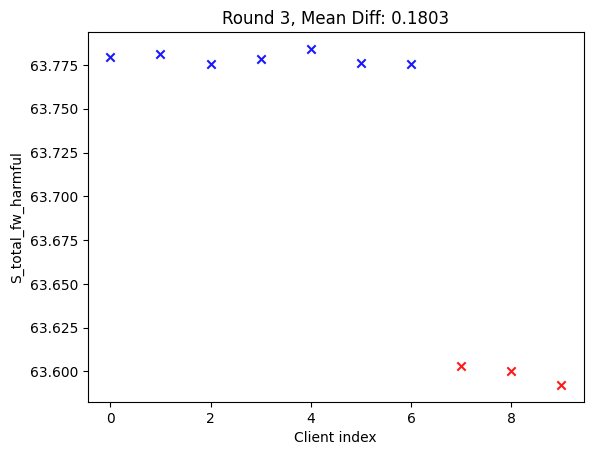

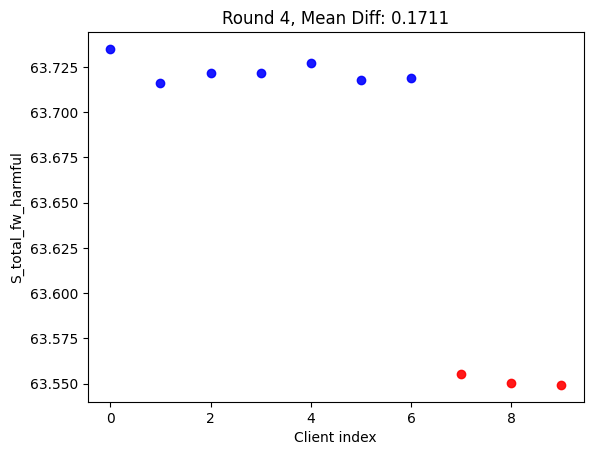

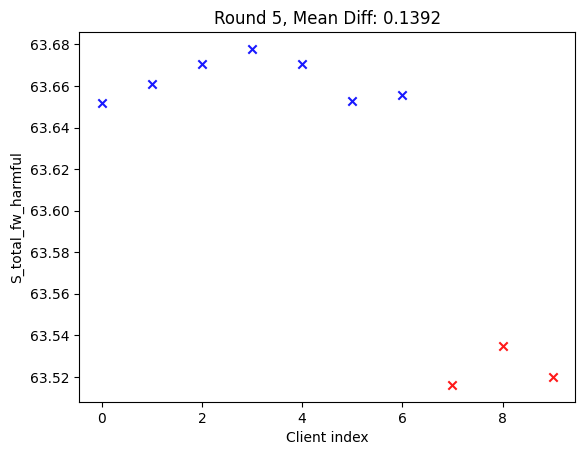

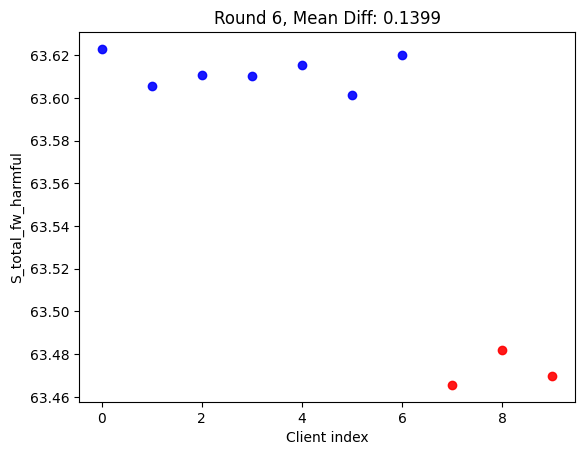

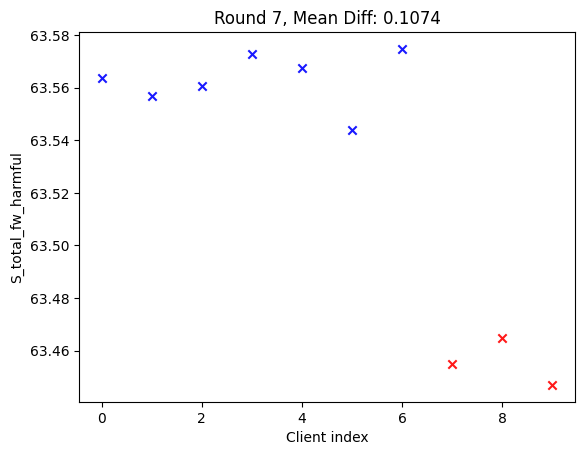

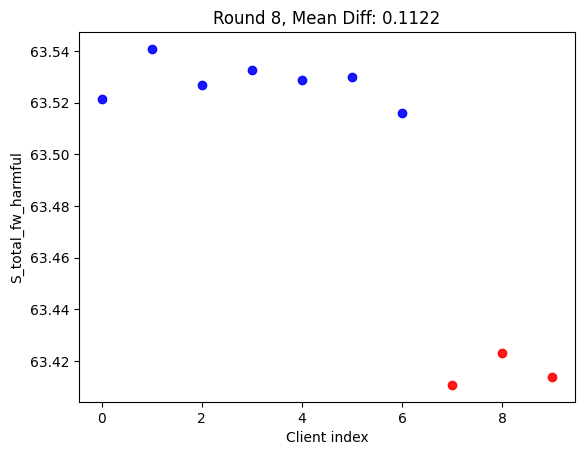

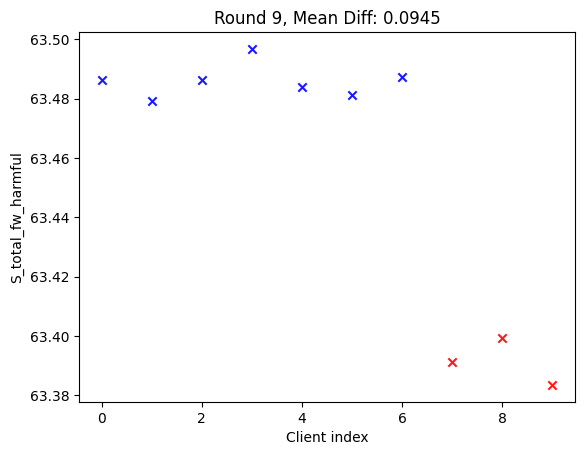

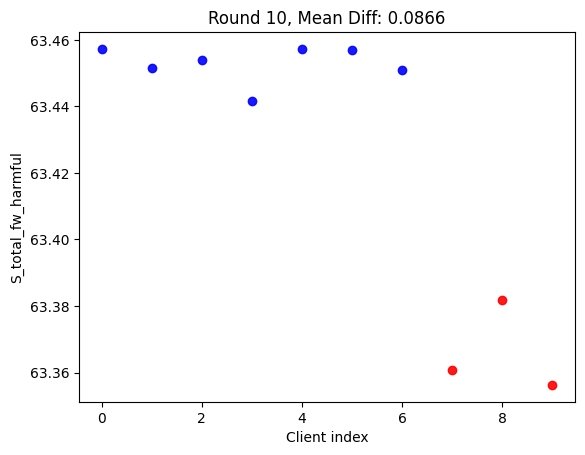

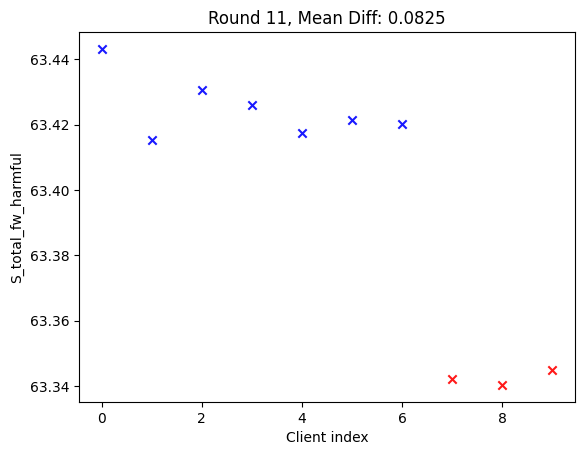

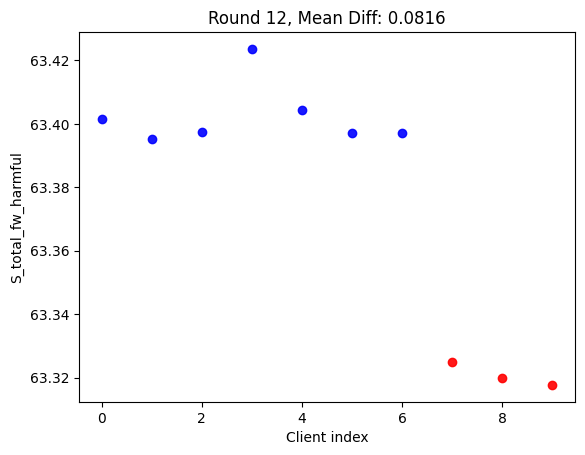

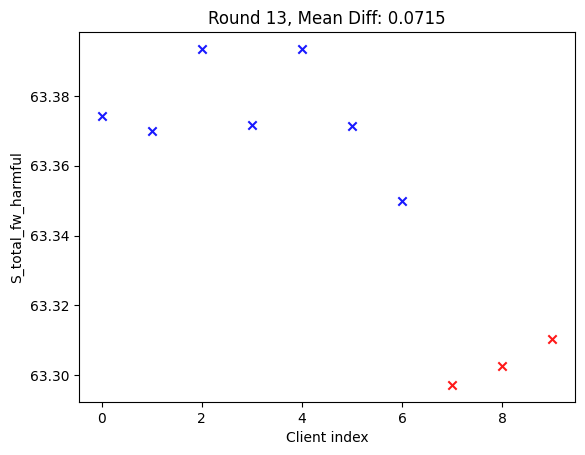

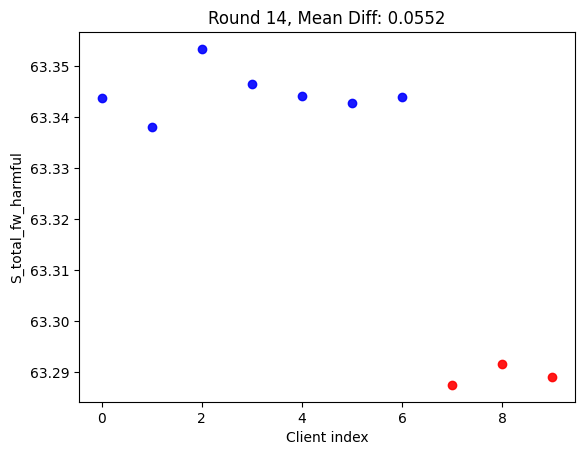

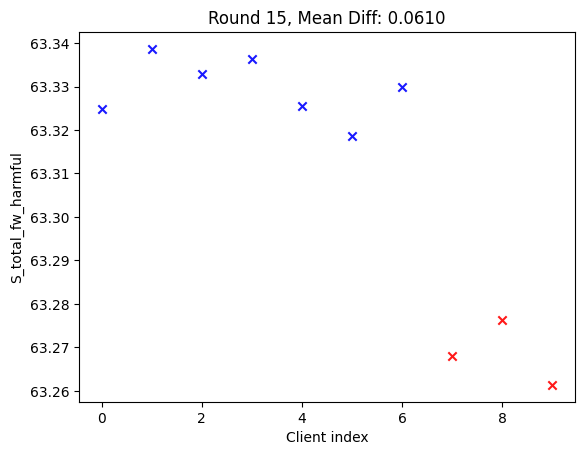

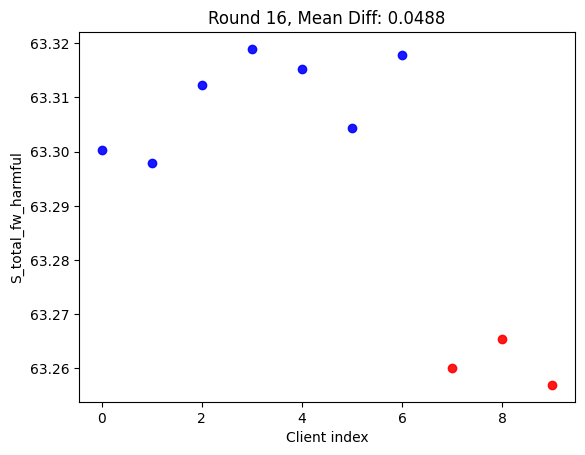

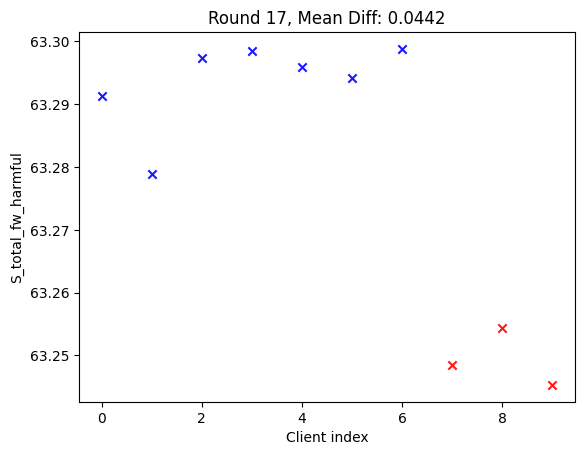

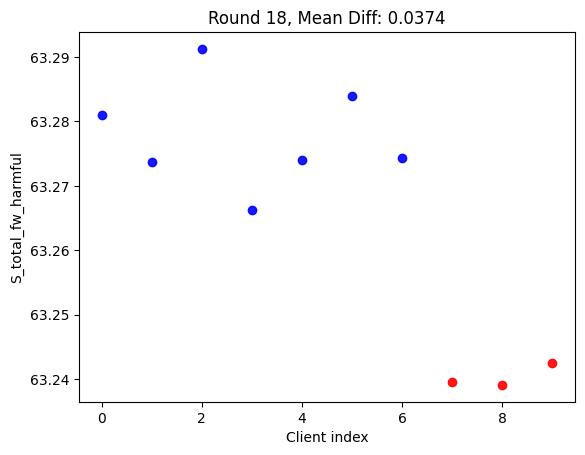

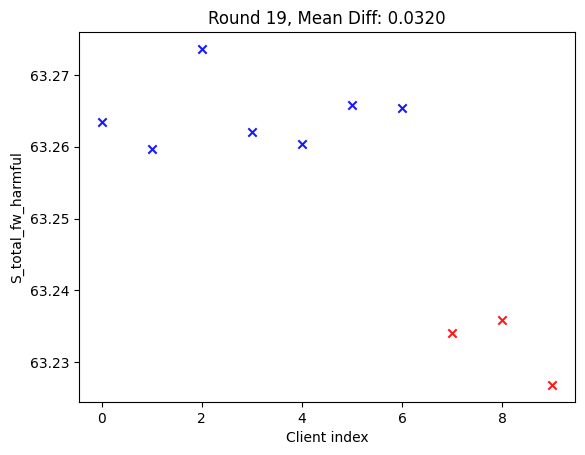

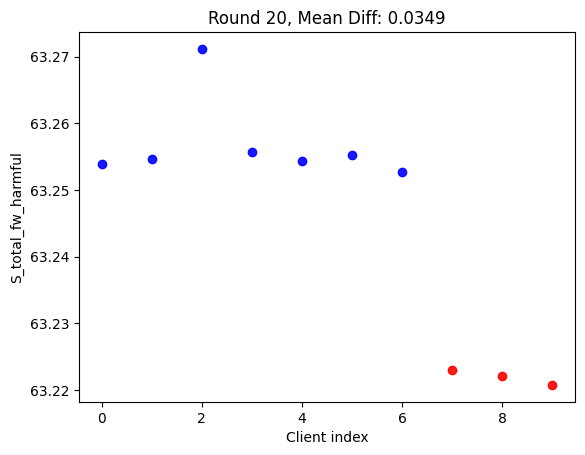

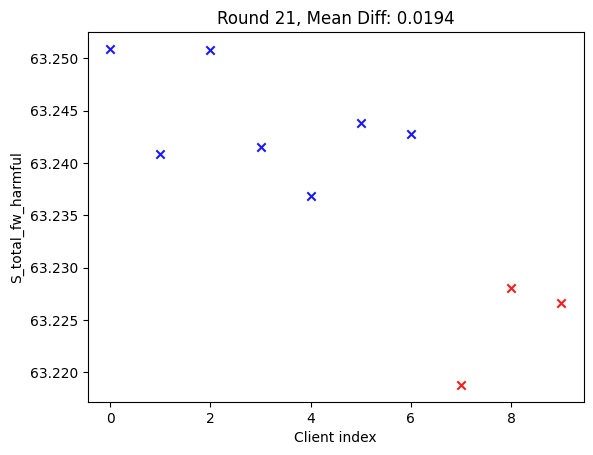

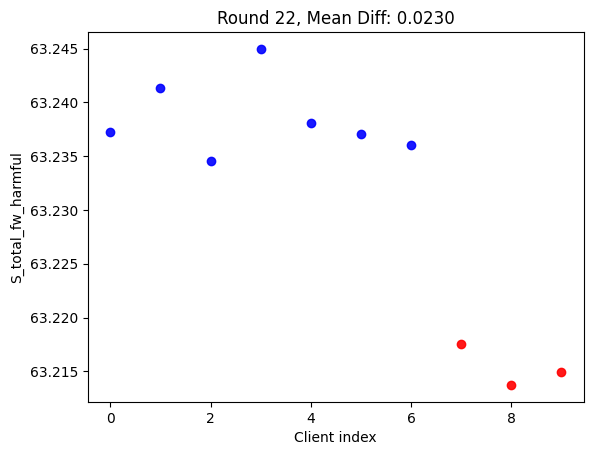

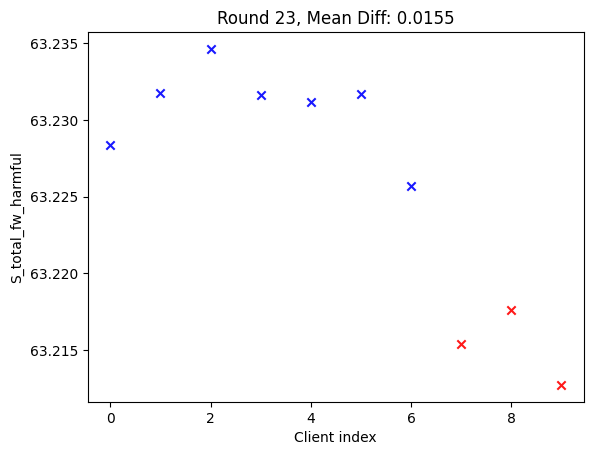

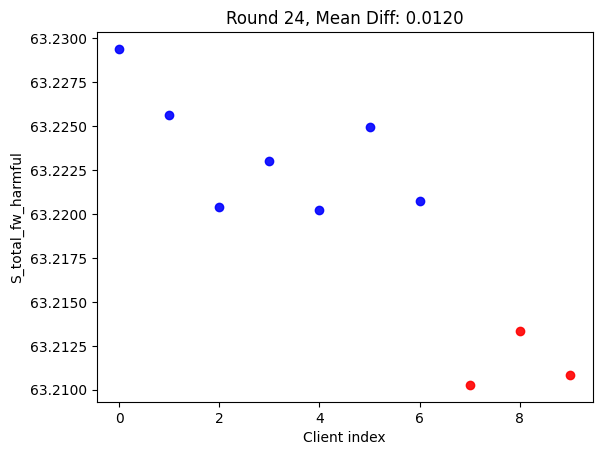

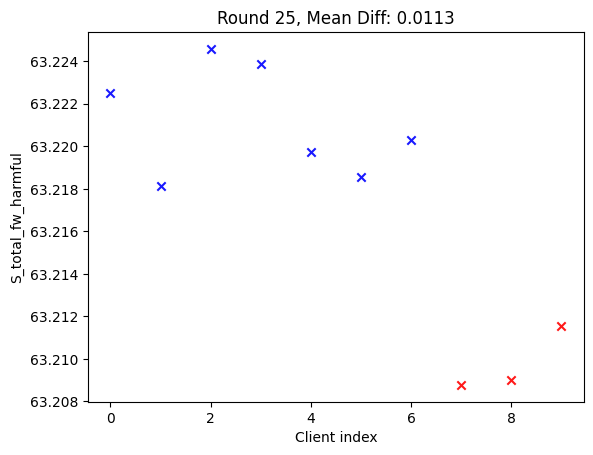

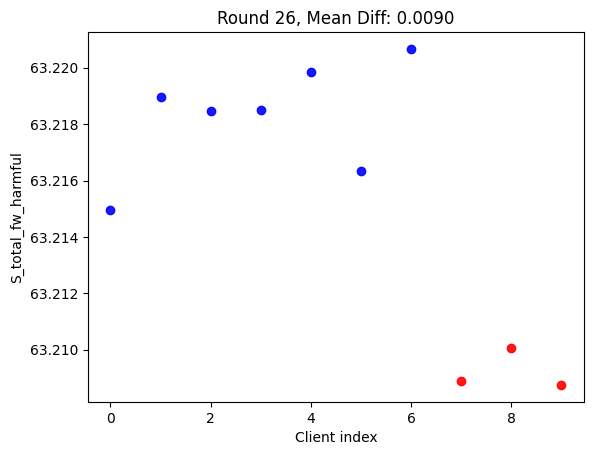

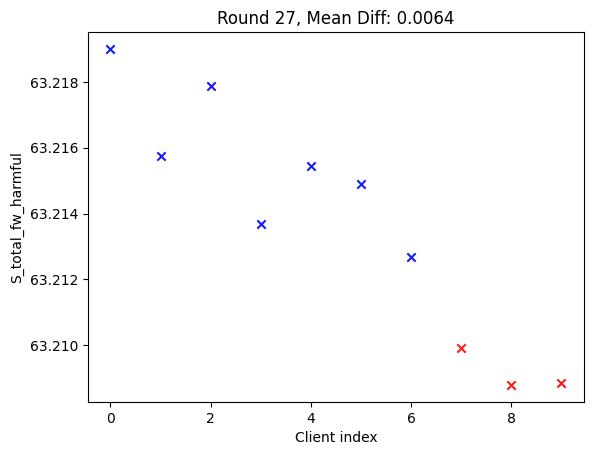

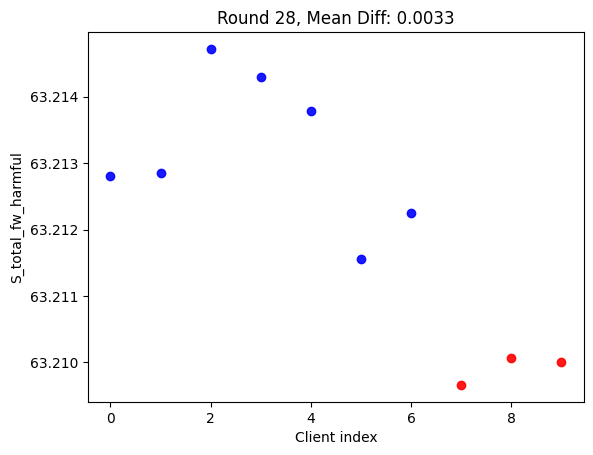

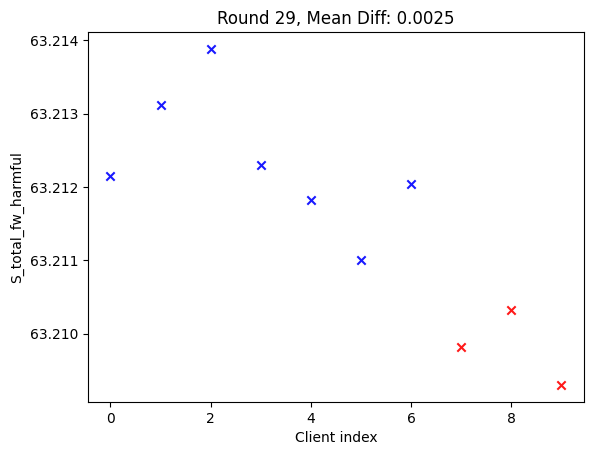

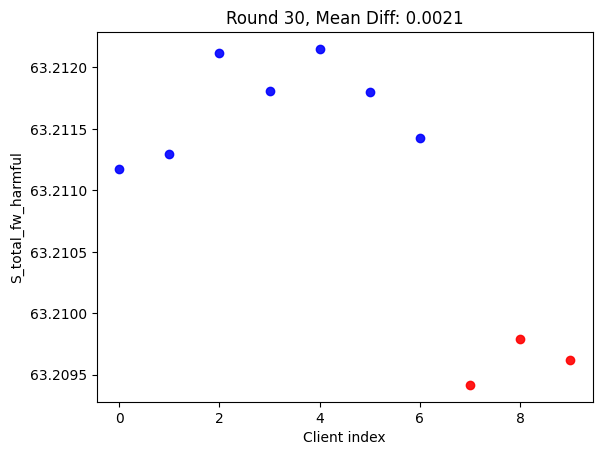

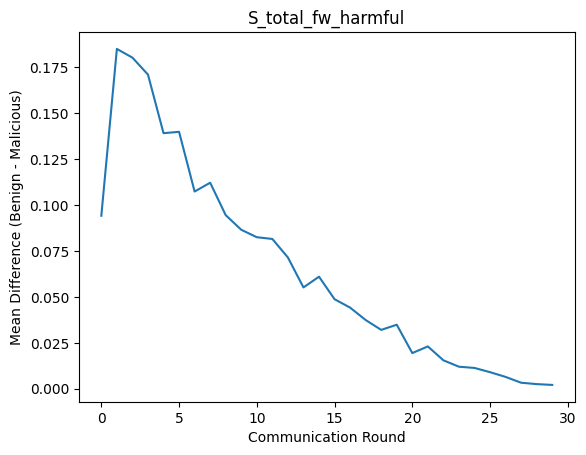

In [10]:
client_benign_ids = [0,1,2,3,4,5, 6]
client_malicious_ids = [7, 8,9]
import matplotlib.pyplot as plt
diffs = []
# "S_total": S_total,
#         "S_total_ori": S_total_ori,
#         "S_total_fw": S_total_fw, 
#         "S_total_fw_harmful": S_total_fw_harmful,
#         "S_total_harmful": S_total_harmful

plot_keys = ['S_total_fw_harmful']

for plot_key in plot_keys:
    for round in range(1, 31):
        if round%2 == 0:
            marker = 'o'
        else:
            marker = 'x'

        cos_per_layer = {client: sum(calculated_safe_lora_data[client][round]['cos_per_layer']) for client in range(0, 10)}
        try:
            S_total = {client: calculated_safe_lora_data[client][round][plot_key] for client in range(0, 10)}
            # cos_per_layer = {client: calculated_safe_lora_data[client][round]['cos_per_layer'].sum() for client in range(0, 10)}
        except:
            
            print("continued")
            continue
        # for key, value in cos_per_layer.items():
        for key, value in S_total.items():
            
            plt.scatter(key, value, color='blue' if int(key) in client_benign_ids else 'red', alpha=0.9, marker=marker)


        # print difference between mean of benign and malicious clients
        benign_values = [v for k, v in S_total.items() if int(k) in client_benign_ids]
        malicious_values = [v for k, v in S_total.items() if int(k) in client_malicious_ids]
        benign_mean = np.mean(benign_values)
        malicious_mean = np.mean(malicious_values)
        diff = benign_mean - malicious_mean
        diffs.append(diff)

        plt.title(f'Round {round}, Mean Diff: {diff:.4f}')
        plt.ylabel(plot_key)
        plt.xlabel("Client index")
        plt.show()

    plt.plot(list(range(len(diffs))), diffs)
    plt.xlabel('Communication Round')
    plt.ylabel('Mean Difference (Benign - Malicious)')
    plt.title(plot_key)
    plt.show()
    diffs = []

        # for key, value in cos_per_layer.items():
        #     plt.plot(list(range(len(value))), value, color='green' if int(key) in client_benign_ids else 'red')
            
    # plt.title(f'Round {round}, Mean Diff: {diff:.4f}')
    # plt.show()

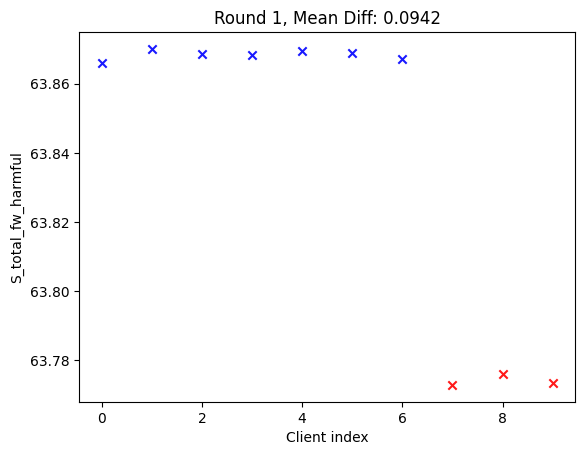

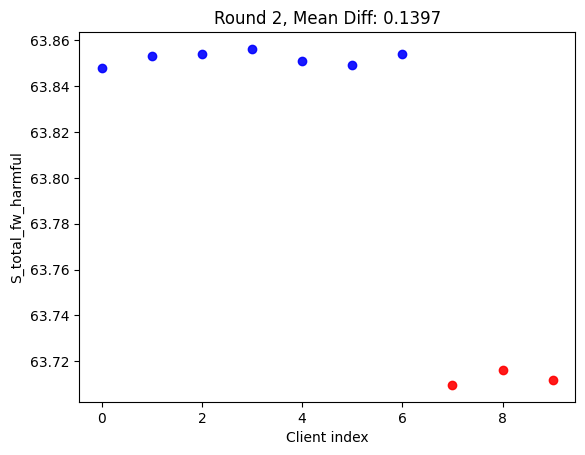

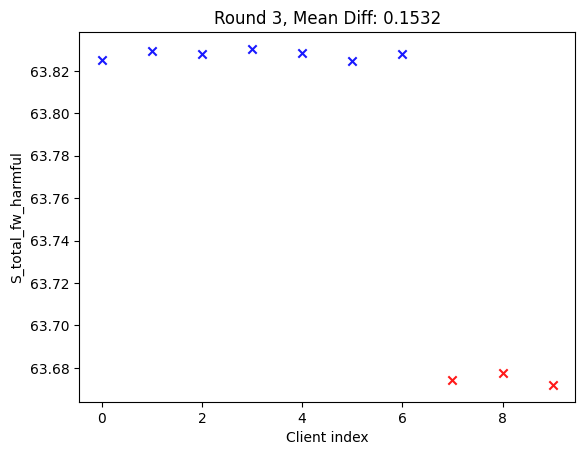

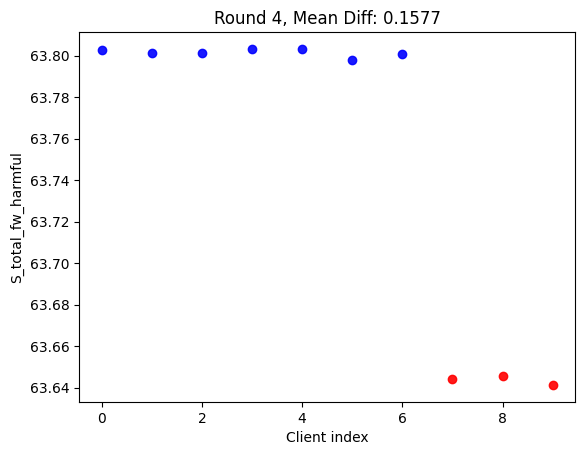

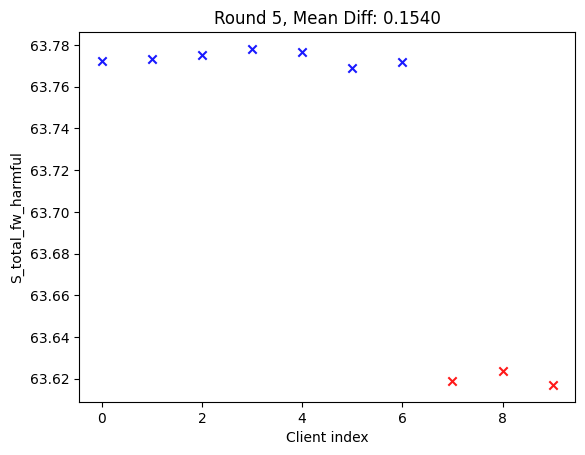

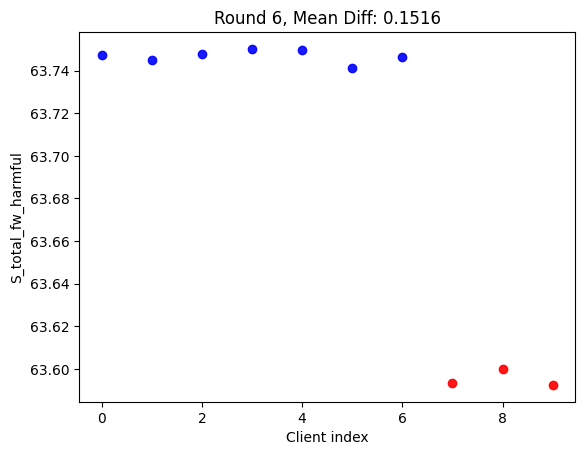

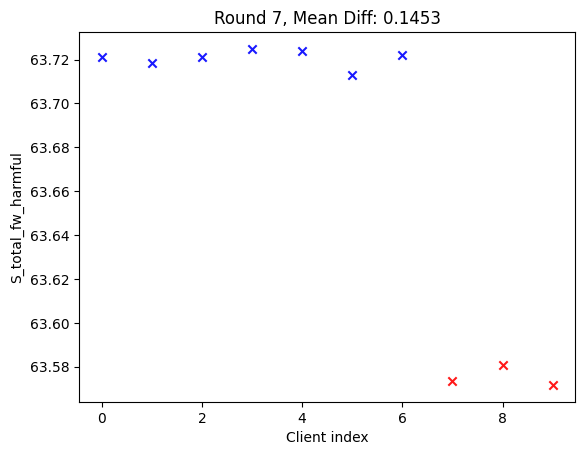

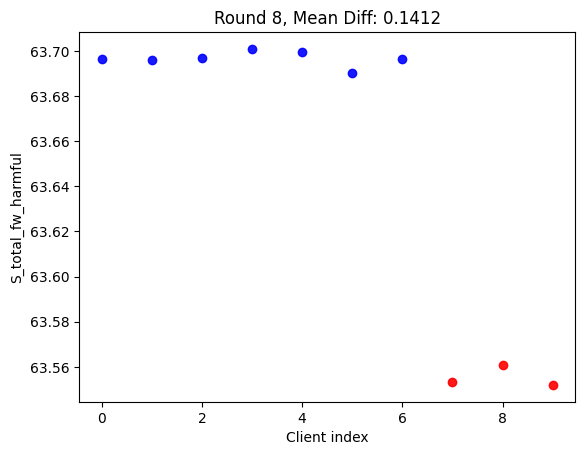

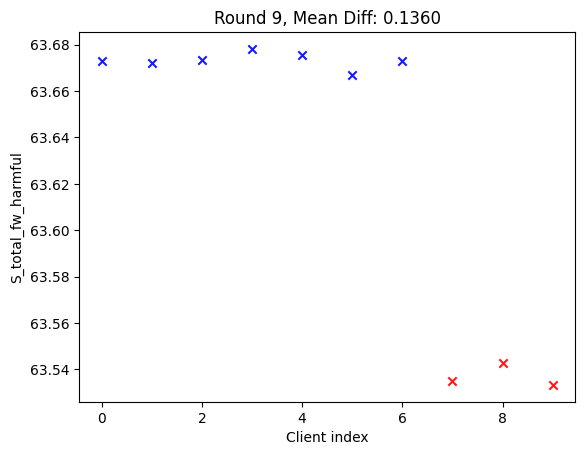

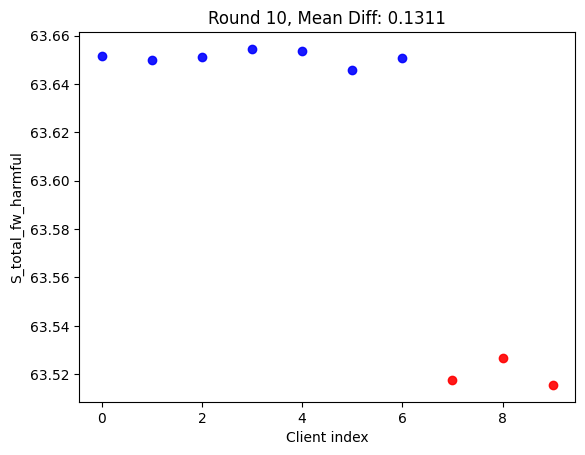

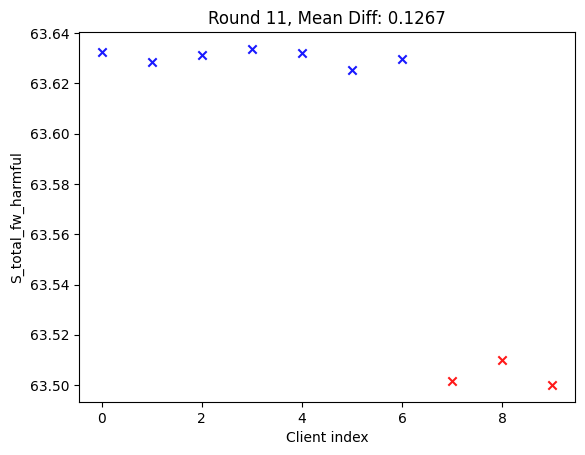

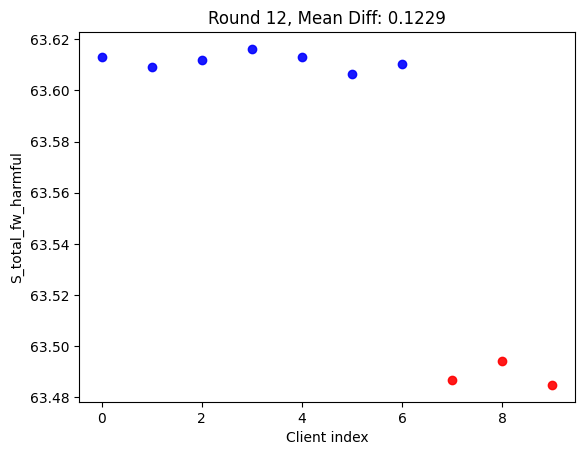

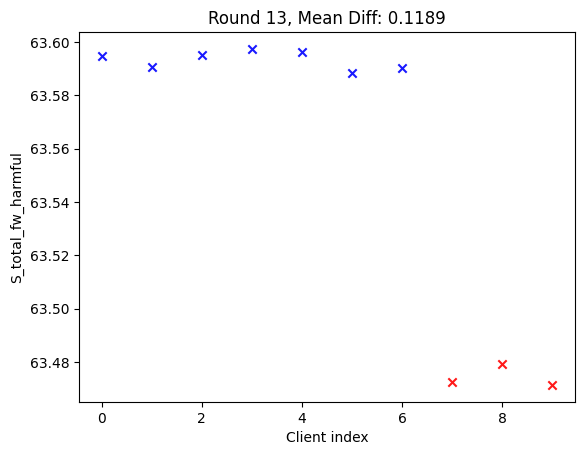

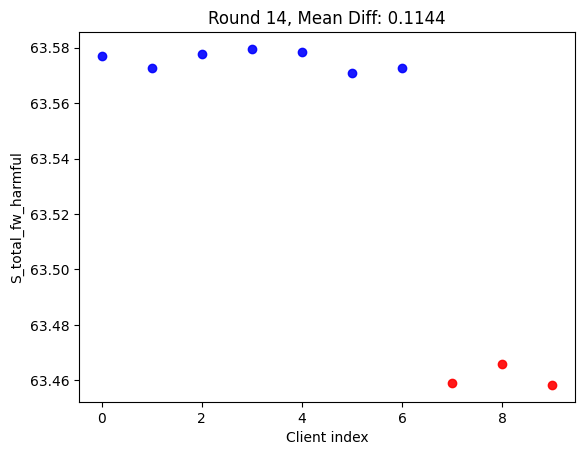

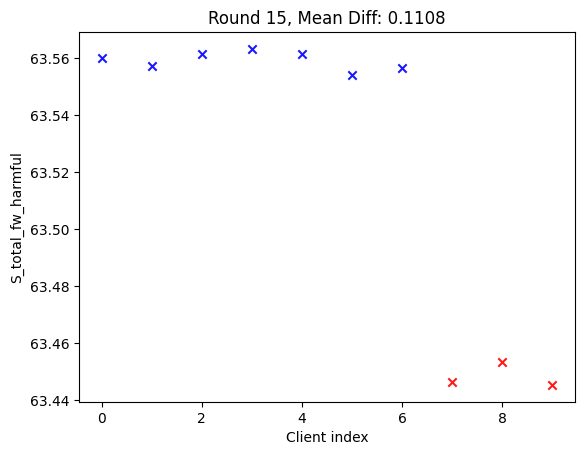

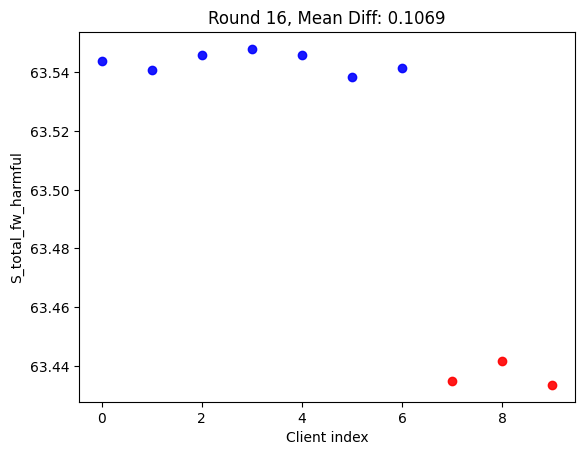

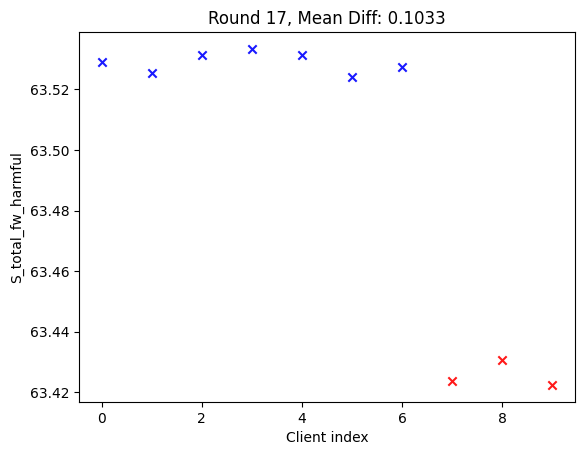

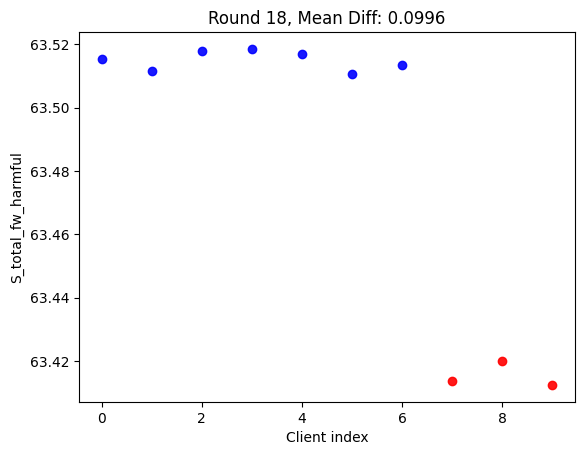

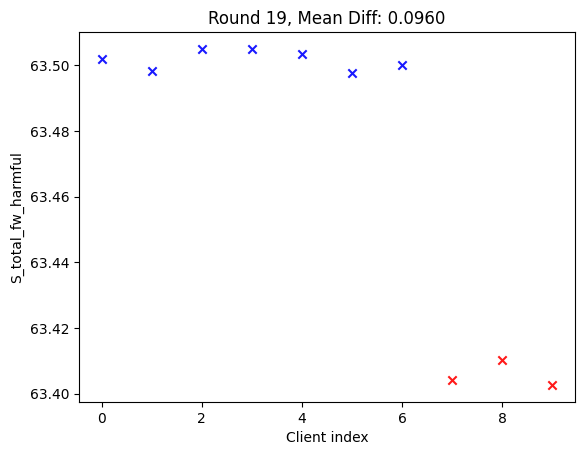

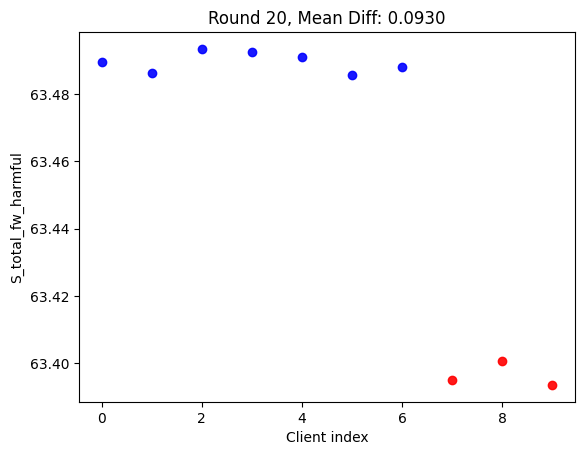

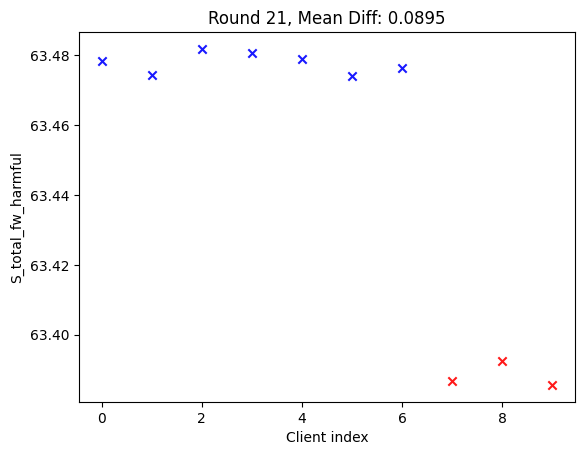

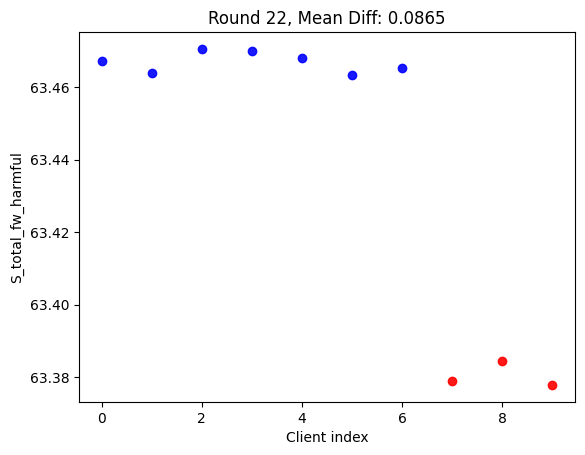

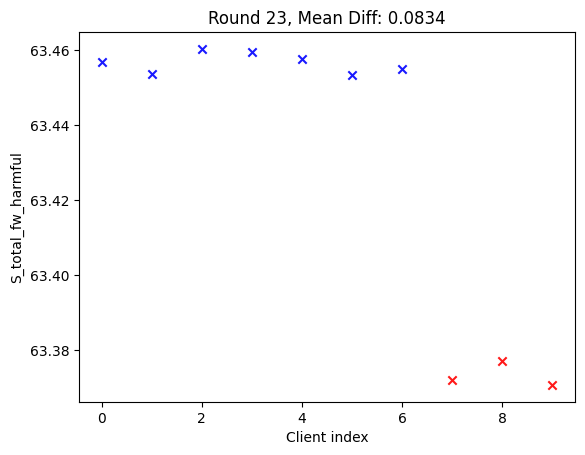

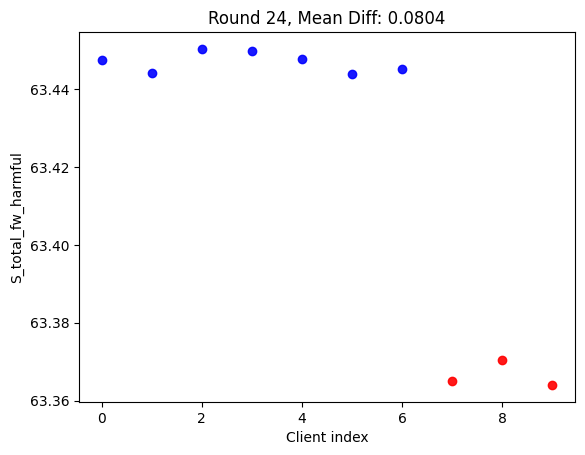

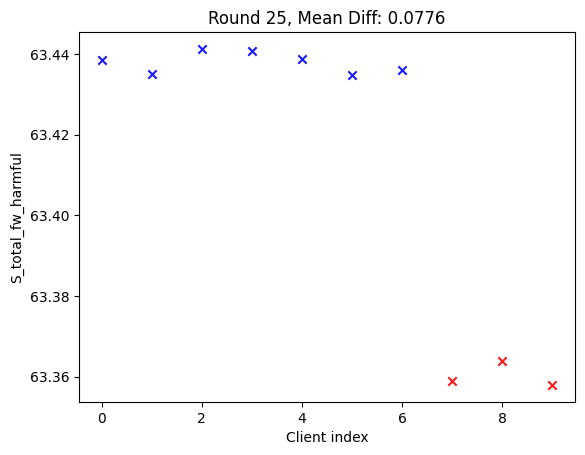

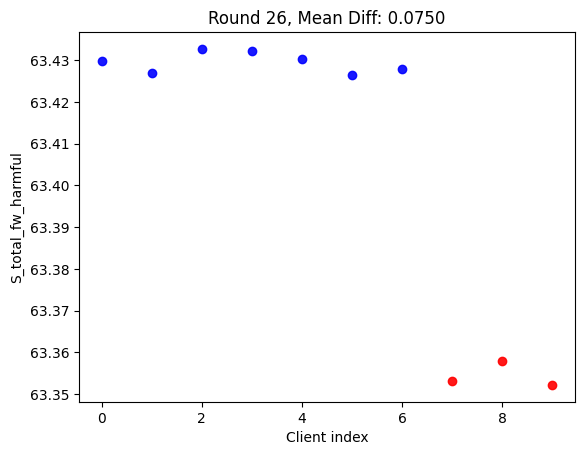

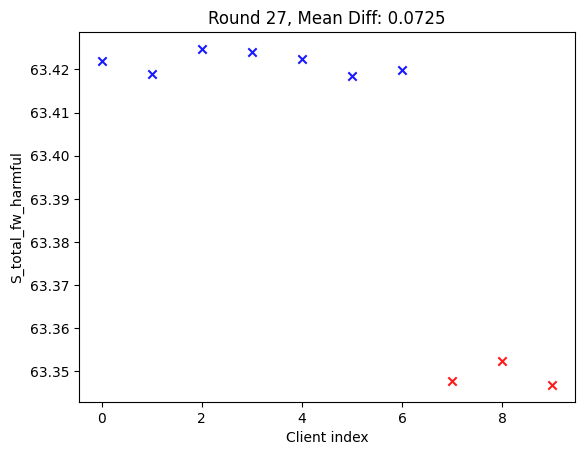

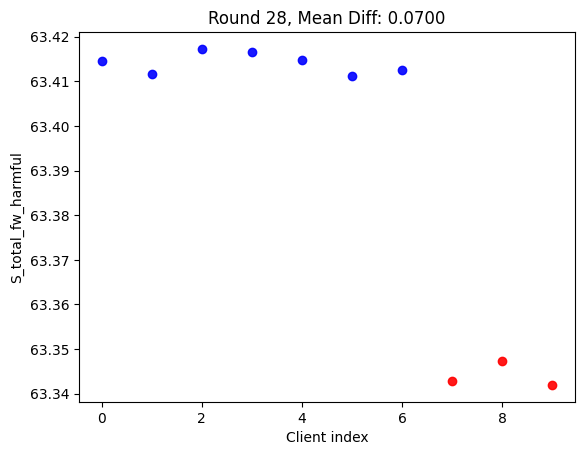

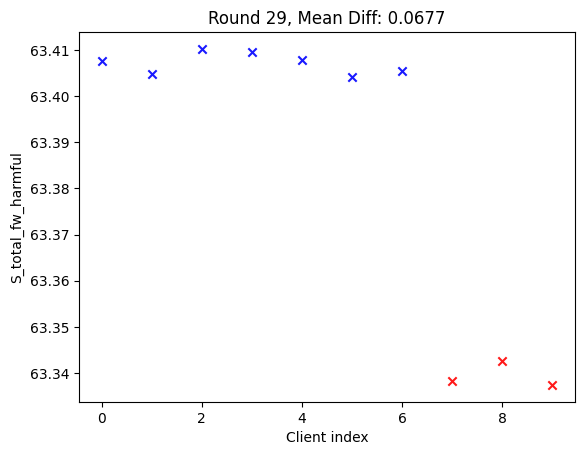

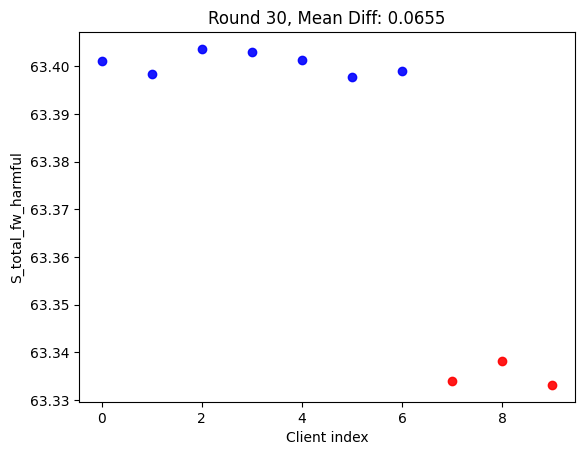

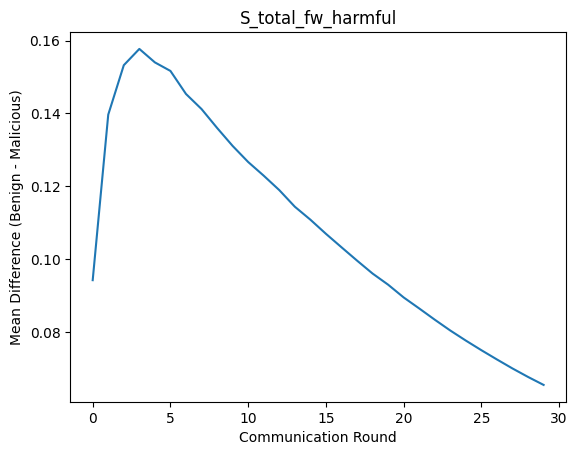

In [11]:
client_benign_ids = [0,1,2,3,4,5, 6]
client_malicious_ids = [7, 8,9]
import matplotlib.pyplot as plt
diffs = []
# "S_total": S_total,
#         "S_total_ori": S_total_ori,
#         "S_total_fw": S_total_fw, 
#         "S_total_fw_harmful": S_total_fw_harmful,
#         "S_total_harmful": S_total_harmful

plot_keys = ['S_total_fw_harmful']

for plot_key in plot_keys:
    cum_sums = {client: 0.0 for client in range(10)}
    cum_counts = {client: 0   for client in range(10)}
    for round in range(1, 31):
        if round%2 == 0:
            marker = 'o'
        else:
            marker = 'x'

        cos_per_layer = {client: sum(calculated_safe_lora_data[client][round]['cos_per_layer']) for client in range(0, 10)}
        try:
            S_total = {client: calculated_safe_lora_data[client][round][plot_key] for client in range(0, 10)}
            # cos_per_layer = {client: calculated_safe_lora_data[client][round]['cos_per_layer'].sum() for client in range(0, 10)}
        except:
            
            print("continued")
            continue
        # for key, value in cos_per_layer.items():

        for client, val in S_total.items():
            cum_sums[client] += val
            cum_counts[client] += 1

        # cumulative average up to this round
        S_total_cumavg = {
            client: (cum_sums[client] / cum_counts[client])
            for client in S_total.keys() if cum_counts[client] > 0
        }

        for key, value in S_total_cumavg.items():
            plt.scatter(key, value, color='blue' if int(key) in client_benign_ids else 'red', alpha=0.9, marker=marker)


        # print difference between mean of benign and malicious clients
        benign_values = [v for k, v in S_total_cumavg.items() if int(k) in client_benign_ids]
        malicious_values = [v for k, v in S_total_cumavg.items() if int(k) in client_malicious_ids]
        benign_mean = np.mean(benign_values)
        malicious_mean = np.mean(malicious_values)
        diff = benign_mean - malicious_mean
        diffs.append(diff)

        plt.title(f'Round {round}, Mean Diff: {diff:.4f}')
        plt.ylabel(plot_key)
        plt.xlabel("Client index")
        plt.show()

    plt.plot(list(range(len(diffs))), diffs)
    plt.xlabel('Communication Round')
    plt.ylabel('Mean Difference (Benign - Malicious)')
    plt.title(plot_key)
    plt.show()
    diffs = []

        # for key, value in cos_per_layer.items():
        #     plt.plot(list(range(len(value))), value, color='green' if int(key) in client_benign_ids else 'red')
            
    # plt.title(f'Round {round}, Mean Diff: {diff:.4f}')
    # plt.show()

In [12]:
# to clean the pickle before loading
import sys, os, glob, pickle

# folder = '/scratch/ps9044/fedllm/barebones/WildChat7_lmsys3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109213209'
folder = '/scratch/ps9044/fedllm/barebones/WildChat2_lmsys2_dromedary2_BeaverTails2_MaliciousGen2_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109200519'
# folder = '/scratch/ps9044/fedllm/barebones/WildChat7_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251106124747'
paths = sorted(glob.glob(os.path.join(folder, 'round_*.pkl')))

argv_bak = sys.argv[:]
sys.argv = ['dummy.py']  # <- not empty!

for p in paths:
    try:
        with open(p, 'rb') as f:
            d = pickle.load(f)
        # drop or flatten fed_args
        d['fed_args'] = None
        clean_p = p.replace('.pkl', '_clean.pkl')
        with open(clean_p, 'wb') as f:
            pickle.dump(d, f, protocol=pickle.HIGHEST_PROTOCOL)
        print('Cleaned:', clean_p)
    except Exception as e:
        print('Failed:', p, e)

sys.argv = argv_bak


Cleaned: /scratch/ps9044/fedllm/barebones/WildChat2_lmsys2_dromedary2_BeaverTails2_MaliciousGen2_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109200519/round_1_clean.pkl
Cleaned: /scratch/ps9044/fedllm/barebones/WildChat2_lmsys2_dromedary2_BeaverTails2_MaliciousGen2_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109200519/round_10_clean.pkl
Cleaned: /scratch/ps9044/fedllm/barebones/WildChat2_lmsys2_dromedary2_BeaverTails2_MaliciousGen2_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109200519/round_11_clean.pkl
Cleaned: /scratch/ps9044/fedllm/barebones/WildChat2_lmsys2_dromedary2_BeaverTails2_MaliciousGen2_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109200519/round_12_clean.pkl
Cleaned: /scratch/ps9044/fedllm/barebones/WildChat2_lmsys2_dromedary2_BeaverTails2_MaliciousGen2_500_fedavg_c10s10_i10_b16a1_l512_r32a64_20251109200519/round_13_clean.pkl
Cleaned: /scratch/ps9044/fedllm/barebones/WildChat2_lmsys2_dromedary2_BeaverTails2_MaliciousGen2_500_fedavg_c10s10_i10_b16a1_l512_r32a64_202511092